In [1]:
import legume

import numpy as np
import matplotlib.pyplot as plt
import time

import autograd.numpy as npa
from autograd import grad, value_and_grad

import legume
from legume.minimize import Minimize

%load_ext autoreload
%autoreload 2

In [2]:
# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

In [3]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep/optimization results to a timestamped folder in data/."""
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n\n')

        f.write('--- Optimization-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

# PhC cavity simulation

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


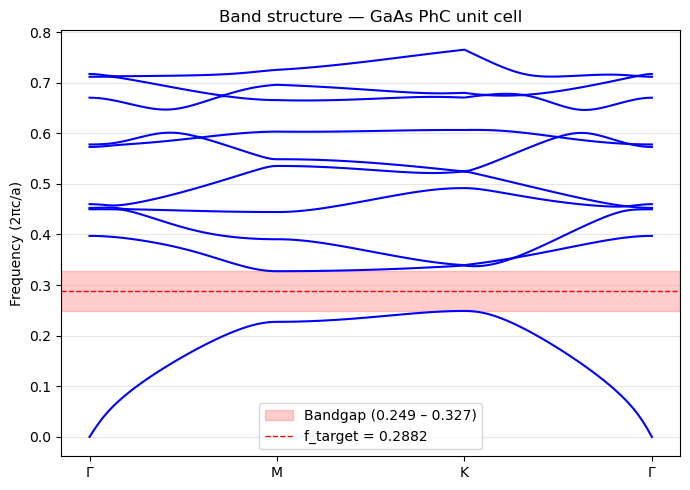

In [4]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────
lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(legume.Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f"Bandgap: {f_lb:.4f} – {f_ub:.4f},  centre f_target = {f_target:.4f}")

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} – {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['Γ', 'M', 'K', 'Γ'])
ax.set_ylabel('Frequency (2πc/a)')
ax.set_title('Band structure — GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='Wave vector', ylabel='Frequency $\\omega a /(2\\pi c)$'>

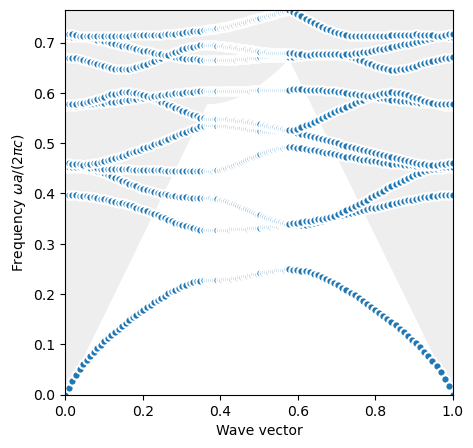

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
legume.viz.bands(gme_bands, ax=ax, k_units=True, Q=False)

In [6]:
# Number of PhC periods in x and y directions
Nx, Ny = 16, 10

# Initialize a lattice and PhC
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Make x and y positions in one quadrant of the supercell
# We only initialize one quadrant because we want to shift the holes symmetrically
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        # Skip the 3 L3 cavity holes:
        #   (ix=0, iy=0) → origin hole (1 hole)
        #   (ix=1, iy=0) → (1,0) and its (-1,0) mirror (2 holes)
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Initialize shift parameters to zeros
dx, dy = np.zeros((nc,)), np.zeros((nc,))

In [7]:

# Define L3 PhC cavity with shifted holes
def cavity(dx, dy):
    # Initialize PhC
    phc = legume.PhotCryst(lattice)

    # Add a layer to the PhC
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    # Apply holes symmetrically in the four quadrants
    for ic, x in enumerate(xp):
        yc = yp[ic] if yp[ic] == 0 else yp[ic] + dy[ic]
        xc = x if x == 0 else xp[ic] + dx[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra))
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra))
        if nx-1.6 > xp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra))

    return phc


In [8]:
# Solve for a cavity defined by shifts dx, dy
def gme_cavity(dx, dy, gmax, truncate_g, options):
    # Initialize PhC
    phc = cavity(dx, dy)

    # For speed, we don't want to compute the loss rates of *all* modes that we store
    options['compute_im'] = False

    # Initialize GME
    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)

    # Solve for the real part of the frequencies
    gme.run(kpoints=np.array([[0], [0]]), **options)

    # Find the imaginary frequency of the fundamental cavity mode
    (freq_im, _, _) = gme.compute_rad(0, [mode_idx])

    # Finally, compute the quality factor
    Q = gme.freqs[0, mode_idx]/2/freq_im[0]
    return (gme, Q)

In [9]:
gmax = 2
truncate_g = 'tbt'  # for large rectangular supercells better to use tbt, it is faster and uses less memory
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Run GME directly for the initial mode-identification pass
phc_init = cavity(dx, dy)
gme = legume.GuidedModeExp(phc_init, gmax=gmax, truncate_g=truncate_g)
gme.run(kpoints=np.array([[0], [0]]), **{**options, 'compute_im': False})

# Identify the L3 cavity mode (first mode inside the bandgap)
print(f"\nModes near bandgap centre (bandgap: {f_lb:.4f} – {f_ub:.4f}):")
mode_idx = None
for i in range(gme.freqs.shape[1]):
    (freq_im_i, _, _) = gme.compute_rad(0, [i])
    Qi = gme.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme.freqs[0, i] < f_ub
    tag = " <-- cavity mode (IN BANDGAP)" if in_gap else ""
    print(f"  Mode {i}: f = {gme.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}")
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError("No mode found inside the bandgap — check f_lb/f_ub or increase numeig")
print(f"\nUsing mode_idx = {mode_idx}")

# Compute Q for the identified cavity mode
(freq_im, _, _) = gme.compute_rad(0, [mode_idx])
Q = gme.freqs[0, mode_idx] / (2 * freq_im[0])

12.227s total time for real part of frequencies in GuidedModeExp, of which
  0.101s (1%) for guided modes computation using the gmode_compute='exact' method
  0.369s (3%) for inverse matrix of Fourier-space permittivity
  10.332s (85%) for matrix diagionalization using the 'eigh' solver
  1.423s (12%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25966,  Q = 6343.7 <-- cavity mode (IN BANDGAP)
  Mode 1: f = 0.27965,  Q = 685.3 <-- cavity mode (IN BANDGAP)
  Mode 2: f = 0.28005,  Q = 557.2 <-- cavity mode (IN BANDGAP)
  Mode 3: f = 0.28180,  Q = 253.3 <-- cavity mode (IN BANDGAP)
  Mode 4: f = 0.28392,  Q = 288.5 <-- cavity mode (IN BANDGAP)
  Mode 5: f = 0.30953,  Q = 686.8 <-- cavity mode (IN BANDGAP)
  Mode 6: f = 0.32352,  Q = 5108.6 <-- cavity mode (IN BANDGAP)
  Mode 7: f = 0.32648,  Q = 781863.3 <-- ca

Cavity quality factor: 6343.69


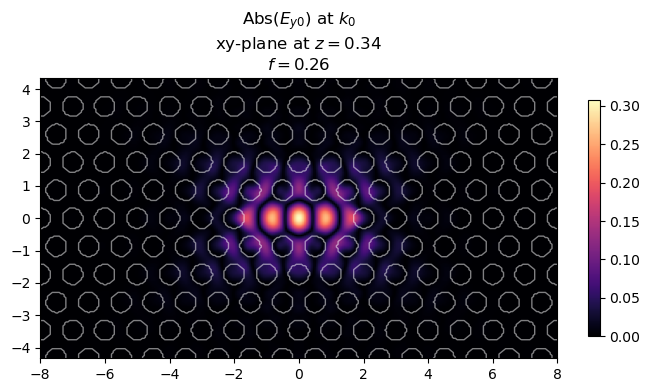

In [10]:
# Print the computed quality factor
print("Cavity quality factor: %1.2f" %Q)

# We can also visualize the cavity and the mode profile of the fundamental mode
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=300, N2=200)

In [11]:
def compute_mode_volume(gme_mv, mind, f_cavity, Nx=500, Ny=300, Nz=25):
    """Compute mode volume V_eff = integral(eps*|E|^2 dV) / max(eps*|E|^2).

    Parameters
    ----------
    gme_mv   : GuidedModeExp -- already solved (numpy backend)
    mind     : int           -- mode index of the cavity mode
    f_cavity : float         -- normalized frequency of the cavity mode (a/lambda)
    Nx, Ny   : int           -- xy resolution per slice
    Nz       : int           -- number of z slices

    Returns
    -------
    V_a3   : float -- mode volume in units of a^3
    V_norm : float -- mode volume in units of (lambda/n_slab)^3
    """
    phc_mv = gme_mv.phc
    slab   = phc_mv.layers[0]

    # z range: slab + half-slab evanescent padding on each side
    z_min = slab.z_min - 0.5 * slab.d
    z_max = slab.z_max + 0.5 * slab.d
    zgrid = np.linspace(z_min, z_max, Nz)

    slices = []
    xgrid_ref = ygrid_ref = None

    for z in zgrid:
        fi, xgrid, ygrid = gme_mv.get_field_xy('e', kind=0, mind=mind,
                                                z=z, component='xyz',
                                                Nx=Nx, Ny=Ny)
        Ex, Ey, Ez = fi['x'], fi['y'], fi['z']

        # Permittivity at this z slice
        xmesh, ymesh = np.meshgrid(xgrid, ygrid)
        zmesh = np.full_like(xmesh, z)
        eps = phc_mv.get_eps((xmesh, ymesh, zmesh))

        slices.append(eps * (np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2))
        if xgrid_ref is None:
            xgrid_ref, ygrid_ref = xgrid, ygrid

    vol_3d = np.stack(slices, axis=0)   # shape: (Nz, Ny, Nx)

    # Triple trapezoidal integration: z first, then y, then x
    numerator = np.trapz(
                    np.trapz(
                        np.trapz(vol_3d, zgrid, axis=0),
                    ygrid_ref, axis=0),
                xgrid_ref, axis=0)
    denominator = float(np.max(vol_3d))
    V_a3 = float(numerator) / denominator

    # Convert to (lambda/n_slab)^3
    lambda_over_n_nm = (a_nm / f_cavity) / n_slab   # lambda/n in nm
    V_norm = V_a3 * (a_nm / lambda_over_n_nm)**3

    return V_a3, V_norm

print("compute_mode_volume defined.")


compute_mode_volume defined.


## Numerical Convergence Tests
Sweep `gmax`, supercell size `(Nx, Ny)`, `numeig`, and `gmode_inds` to verify the simulation parameters produce converged Q factors and cavity frequencies.

In [12]:
def run_convergence_test(Nx_t, Ny_t, gmax_t, numeig_t, gmode_inds_t,
                         ra_t=ra, dslab_t=dslab, n_slab_t=n_slab,
                         f_target_t=f_target, f_lb_t=f_lb, f_ub_t=f_ub,
                         shifts=None, f_ref=None,
                         truncate_g='tbt', gmode_step=1e-2):
    """Run a single L3 cavity simulation and return (Q, freq, npw).

    Mode selection:
      - If f_ref is given: pick the bandgap mode closest in frequency to f_ref.
      - If f_ref is None:  pick the first mode inside the bandgap (lowest freq).
    This avoids selecting spurious high-Q bulk modes.
    """
    # Build supercell lattice
    lat = legume.Lattice([Nx_t, 0], [0, Ny_t * np.sqrt(3) / 2])

    # Build hole positions in one quadrant (skipping L3 defect holes)
    xp_t, yp_t = [], []
    nx_t, ny_t = Nx_t // 2 + 1, Ny_t // 2 + 1
    for iy in range(ny_t):
        for ix in range(nx_t):
            if iy == 0 and ix in (0, 1):
                continue
            xp_t.append(ix + (iy % 2) * 0.5)
            yp_t.append(iy * np.sqrt(3) / 2)

    # Apply hole shifts (if any)
    dx_t = [0.0] * len(xp_t)
    if shifts is not None:
        for (ic, dx_val) in shifts:
            if ic < len(dx_t):
                dx_t[ic] = dx_val

    # Build PhC with symmetric holes in four quadrants
    phc = legume.PhotCryst(lat)
    phc.add_layer(d=dslab_t, eps_b=n_slab_t**2)
    for ic, x in enumerate(xp_t):
        yc = yp_t[ic]
        xc = x if x == 0 else x + dx_t[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra_t))
        if nx_t - 0.6 > xp_t[ic] > 0 and (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra_t))
        if nx_t - 1.6 > xp_t[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra_t))
        if (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0 and nx_t - 1.1 > xp_t[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra_t))

    # Run GME
    eig_sigma = f_ref if f_ref is not None else f_target_t
    gme_t = legume.GuidedModeExp(phc, gmax=gmax_t, truncate_g=truncate_g)
    gme_t.run(kpoints=np.array([[0], [0]]),
              gmode_inds=gmode_inds_t, verbose=False,
              numeig=numeig_t, eig_sigma=eig_sigma,
              compute_im=False, gradients='approx',
              gmode_step=gmode_step)

    npw = gme_t.gvec.shape[1]

    # Mode selection
    all_freqs = gme_t.freqs[0, :]

    if f_ref is not None:
        # Track by frequency: find the bandgap mode closest to f_ref
        best_idx, best_dist = None, float('inf')
        for i in range(gme_t.freqs.shape[1]):
            fi = all_freqs[i]
            if not (f_lb_t < fi < f_ub_t):
                continue
            dist = abs(fi - f_ref)
            if dist < best_dist:
                best_dist, best_idx = dist, i
    else:
        # No reference: pick the first (lowest-frequency) mode in the bandgap
        best_idx = None
        for i in range(gme_t.freqs.shape[1]):
            if f_lb_t < all_freqs[i] < f_ub_t:
                best_idx = i
                break

    if best_idx is not None:
        (freq_im, _, _) = gme_t.compute_rad(0, [best_idx])
        Q_t = all_freqs[best_idx] / (2 * freq_im[0])
        return (Q_t, float(all_freqs[best_idx]), npw)
    return (None, None, npw)

print("Convergence test helper defined (frequency-tracking mode selection).")


Convergence test helper defined (frequency-tracking mode selection).


Step 1: gmax convergence (gmode_inds=[0])
    gmax     npw             Q        freq
  --------------------------------------
     1.5    1225        6120.9     0.25880
     2.0    2275        6343.7     0.25966
     2.5    3483        6595.9     0.26007
     3.0    4947        6720.6     0.26036

  Relative change (last two): Q = 1.89%, freq = 0.1114%


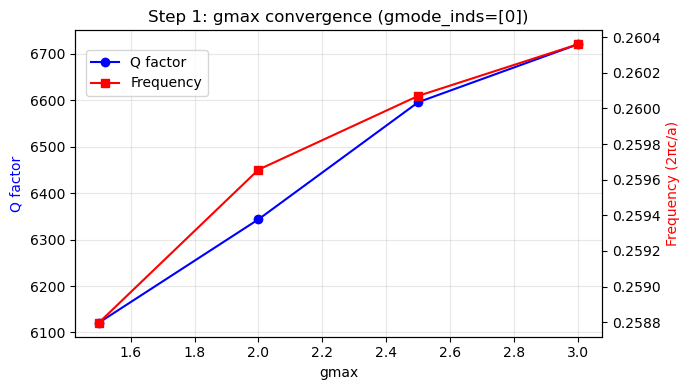

In [13]:
# --- FAQ Step 1: gmax convergence (gmode_inds=[0]) ---
gmax_values = [1.5, 2.0, 2.5, 3.0]
gmax_results = []

print("Step 1: gmax convergence (gmode_inds=[0])")
print(f"  {'gmax':>6s}  {'npw':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 38)
for gm in gmax_values:
    Q_t, f_t, npw = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=gm,
                                          numeig_t=10, gmode_inds_t=[0])
    gmax_results.append((Q_t, f_t, npw))
    print(f"  {gm:6.1f}  {npw:6d}  {Q_t:12.1f}  {f_t:10.5f}")

dQ = abs(gmax_results[-1][0] - gmax_results[-2][0]) / gmax_results[-2][0] * 100
df = abs(gmax_results[-1][1] - gmax_results[-2][1]) / gmax_results[-2][1] * 100
print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(gmax_values, [r[0] for r in gmax_results], 'bo-', lw=1.5, label='Q factor')
ax2.plot(gmax_values, [r[1] for r in gmax_results], 'rs-', lw=1.5, label='Frequency')
ax1.set_xlabel('gmax')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2\u03c0c/a)', color='r')
ax1.set_title('Step 1: gmax convergence (gmode_inds=[0])')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


In [ ]:
# --- FAQ Step 2: gmode_inds convergence (at highest gmax) ---
gmode_configs = [[0], [0, 1], [0, 1, 2]]
gmode_results = []

print("Step 2: gmode_inds convergence (gmax=3.0)")
print(f"  {'gmode_inds':>12s}  {'npw':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 44)
for gm_inds in gmode_configs:
    Q_t, f_t, npw = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=3.0,
                                          numeig_t=10, gmode_inds_t=gm_inds)
    gmode_results.append((Q_t, f_t, npw))
    label = str(gm_inds)
    if Q_t is not None:
        print(f"  {label:>12s}  {npw:6d}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  {label:>12s}  {npw:6d}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f, _ in gmode_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
valid_Q = [Q for Q, _, _ in gmode_results if Q is not None]
valid_f = [f for _, f, _ in gmode_results if f is not None]
x_pos = list(range(len(valid_Q)))
ax1.plot(x_pos, valid_Q, 'bo-', lw=1.5, label='Q factor')
ax2.plot(x_pos, valid_f, 'rs-', lw=1.5, label='Frequency')
ax1.set_xticks(range(len(gmode_configs)))
ax1.set_xticklabels([str(g) for g in gmode_configs])
ax1.set_xlabel('gmode_inds')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2\u03c0c/a)', color='r')
ax1.set_title('Step 2: gmode_inds convergence (gmax=3.0)')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


Step 2: gmode_inds convergence (gmax=3.0)
    gmode_inds     npw             Q        freq
  --------------------------------------------
           [0]    4947        6720.6     0.26036
        [0, 1]    4947          76.5     0.28503


In [ ]:
# --- FAQ Step 3: gmax re-check with more guided modes ---
# Re-run gmax sweep using the largest gmode_inds set from Step 2
gmode_converged = [0, 1, 2]
gmax_recheck_results = []

print(f"Step 3: gmax re-check (gmode_inds={gmode_converged})")
print(f"  {'gmax':>6s}  {'npw':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 38)
for gm in gmax_values:
    Q_t, f_t, npw = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=gm,
                                          numeig_t=10, gmode_inds_t=gmode_converged)
    gmax_recheck_results.append((Q_t, f_t, npw))
    if Q_t is not None:
        print(f"  {gm:6.1f}  {npw:6d}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  {gm:6.1f}  {npw:6d}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f, _ in gmax_recheck_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

# Compare with Step 1 (gmode_inds=[0]) on same plot
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(gmax_values, [r[0] for r in gmax_results], 'bo--', lw=1, ms=4, alpha=0.5, label='Q (gmode=[0])')
ax1.plot(gmax_values, [r[0] for r in gmax_recheck_results if r[0] is not None],
         'bo-', lw=1.5, ms=6, label=f'Q (gmode={gmode_converged})')
ax2.plot(gmax_values, [r[1] for r in gmax_results], 'rs--', lw=1, ms=4, alpha=0.5)
ax2.plot(gmax_values, [r[1] for r in gmax_recheck_results if r[1] is not None],
         'rs-', lw=1.5, ms=6)
ax1.set_xlabel('gmax')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2\u03c0c/a)', color='r')
ax1.set_title('Step 3: gmax re-check with more guided modes')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# --- Supercell size convergence ---
supercell_sizes = [(8, 6), (12, 8), (16, 10), (20, 12)]
size_results = []

print("Supercell size convergence:")
print(f"  {'(Nx,Ny)':>10s}  {'npw':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 42)
for (Nx_t, Ny_t) in supercell_sizes:
    Q_t, f_t, npw = run_convergence_test(Nx_t=Nx_t, Ny_t=Ny_t, gmax_t=2.0,
                                          numeig_t=10, gmode_inds_t=[0])
    size_results.append((Q_t, f_t, npw))
    if Q_t is not None:
        print(f"  ({Nx_t:2d},{Ny_t:2d})    {npw:6d}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  ({Nx_t:2d},{Ny_t:2d})    {npw:6d}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f, _ in size_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

labels = [f"({n},{m})" for n, m in supercell_sizes]
valid_idx = [i for i, (Q, _, _) in enumerate(size_results) if Q is not None]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(valid_idx, [size_results[i][0] for i in valid_idx], 'bo-', lw=1.5, label='Q factor')
ax2.plot(valid_idx, [size_results[i][1] for i in valid_idx], 'rs-', lw=1.5, label='Frequency')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_xlabel('Supercell (Nx, Ny)')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2\u03c0c/a)', color='r')
ax1.set_title('Supercell size convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


In [ ]:
# --- numeig convergence ---
numeig_values = [6, 8, 10, 15, 20]
numeig_results = []

print("numeig convergence:")
print(f"  {'numeig':>8s}  {'npw':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 40)
for ne in numeig_values:
    Q_t, f_t, npw = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=2.0,
                                          numeig_t=ne, gmode_inds_t=[0])
    numeig_results.append((Q_t, f_t, npw))
    if Q_t is not None:
        print(f"  {ne:8d}  {npw:6d}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  {ne:8d}  {npw:6d}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f, _ in numeig_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
valid_ne = [numeig_values[i] for i, (Q, _, _) in enumerate(numeig_results) if Q is not None]
valid_Q = [Q for Q, _, _ in numeig_results if Q is not None]
valid_f = [f for _, f, _ in numeig_results if f is not None]
ax1.plot(valid_ne, valid_Q, 'bo-', lw=1.5, label='Q factor')
ax2.plot(valid_ne, valid_f, 'rs-', lw=1.5, label='Frequency')
ax1.set_xlabel('numeig')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2\u03c0c/a)', color='r')
ax1.set_title('numeig convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


In [ ]:
# --- Convergence summary (FAQ order) ---
THRESHOLD = 5.0  # percent

def rel_change(results):
    """Relative change (%) between last two valid (Q, freq) pairs."""
    valid = [(Q, f) for Q, f, *_ in results if Q is not None]
    if len(valid) < 2:
        return None, None
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    return dQ, df

sweeps = {
    'gmax (Step 1)':          gmax_results,
    'gmode_inds (Step 2)':    gmode_results,
    'gmax recheck (Step 3)':  gmax_recheck_results,
    'supercell':              size_results,
    'numeig':                 numeig_results,
}

print("=" * 62)
print("  CONVERGENCE SUMMARY (following legume FAQ procedure)")
print("=" * 62)
print(f"  {'Parameter':>22s}  {'dQ (%)':>10s}  {'df (%)':>10s}  {'Status':>8s}")
print("  " + "-" * 54)

all_pass = True
for name, results in sweeps.items():
    dQ, df = rel_change(results)
    if dQ is None:
        status = "NO DATA"
        all_pass = False
    elif dQ > THRESHOLD or df > THRESHOLD:
        status = "WARN"
        all_pass = False
    else:
        status = "OK"
    dQ_str = f"{dQ:.2f}" if dQ is not None else "N/A"
    df_str = f"{df:.4f}" if df is not None else "N/A"
    print(f"  {name:>22s}  {dQ_str:>10s}  {df_str:>10s}  {status:>8s}")

print("  " + "-" * 54)
if all_pass:
    print("  All parameters converged (< 5% change between last two values).")
else:
    print("  WARNING: Some parameters show >5% change \u2014 consider increasing them.")


### Truncation Scheme Comparison: abs vs tbt
Compare the circular (`abs`) and parallelogram (`tbt`) reciprocal-space truncation schemes.
For a hexagonal lattice, `abs` preserves rotational symmetry while `tbt` does not.
At the same `gmax`, the two schemes produce different numbers of plane waves (npw).

Truncation comparison (abs vs tbt), unoptimized cavity:
    gmax         Q_abs   npw_abs   t_abs(s)         Q_tbt   npw_tbt   t_tbt(s)    dQ(%)
  --------------------------------------------------------------------------------
Plane waves used in the expansion = 973.
     1.5        6022.3       973       3.51        6120.9      1225       2.33     1.61
Plane waves used in the expansion = 1755.
     2.0        6270.0      1755       9.56        6343.7      2275      16.64     1.16
Plane waves used in the expansion = 2715.
     2.5        6414.1      2715      27.20        6595.9      3483      43.68     2.76
Plane waves used in the expansion = 3911.
     3.0        6662.4      3911      78.17        6720.6      4947     115.20     0.87

  Total: abs = 118.5s,  tbt = 177.9s,  speedup = 0.67x


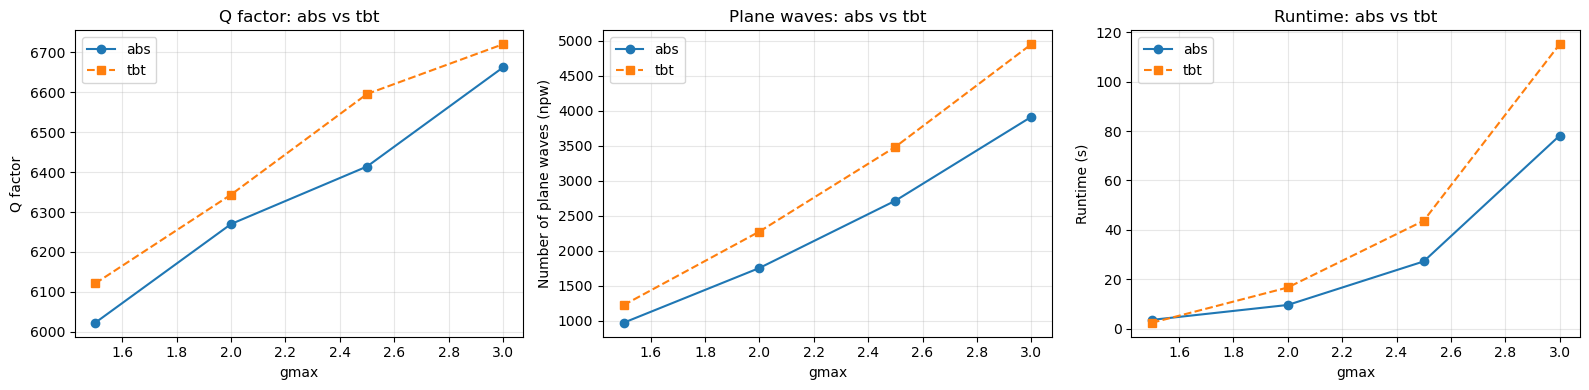

In [ ]:
# --- abs vs tbt truncation comparison (unoptimized cavity) ---
import time as _time

gmax_trunc_vals = [1.5, 2.0, 2.5, 3.0]

results_abs, results_tbt = [], []
times_abs, times_tbt = [], []

print("Truncation comparison (abs vs tbt), unoptimized cavity:")
print(f"  {'gmax':>6s}  {'Q_abs':>12s}  {'npw_abs':>8s}  {'t_abs(s)':>9s}  {'Q_tbt':>12s}  {'npw_tbt':>8s}  {'t_tbt(s)':>9s}  {'dQ(%)':>7s}")
print("  " + "-" * 80)

for gm in gmax_trunc_vals:
    t0 = _time.time()
    Q_a, f_a, npw_a = run_convergence_test(16, 10, gm, 10, [0], truncate_g='abs')
    t_abs = _time.time() - t0
    times_abs.append(t_abs)

    t0 = _time.time()
    Q_t, f_t, npw_t = run_convergence_test(16, 10, gm, 10, [0], truncate_g='tbt')
    t_tbt = _time.time() - t0
    times_tbt.append(t_tbt)

    results_abs.append((Q_a, f_a, npw_a))
    results_tbt.append((Q_t, f_t, npw_t))
    dQ_pct = abs(Q_a - Q_t) / max(Q_a, Q_t) * 100 if Q_a and Q_t else float('nan')
    print(f"  {gm:6.1f}  {Q_a:12.1f}  {npw_a:8d}  {t_abs:9.2f}  {Q_t:12.1f}  {npw_t:8d}  {t_tbt:9.2f}  {dQ_pct:7.2f}")

print(f"\n  Total: abs = {sum(times_abs):.1f}s,  tbt = {sum(times_tbt):.1f}s,  speedup = {sum(times_abs)/sum(times_tbt):.2f}x")

# Plot: 3 panels — Q, npw, runtime
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(gmax_trunc_vals, [r[0] for r in results_abs], 'o-', lw=1.5, label='abs')
ax1.plot(gmax_trunc_vals, [r[0] for r in results_tbt], 's--', lw=1.5, label='tbt')
ax1.set_xlabel('gmax')
ax1.set_ylabel('Q factor')
ax1.set_title('Q factor: abs vs tbt')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(gmax_trunc_vals, [r[2] for r in results_abs], 'o-', lw=1.5, label='abs')
ax2.plot(gmax_trunc_vals, [r[2] for r in results_tbt], 's--', lw=1.5, label='tbt')
ax2.set_xlabel('gmax')
ax2.set_ylabel('Number of plane waves (npw)')
ax2.set_title('Plane waves: abs vs tbt')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(gmax_trunc_vals, times_abs, 'o-', lw=1.5, label='abs')
ax3.plot(gmax_trunc_vals, times_tbt, 's--', lw=1.5, label='tbt')
ax3.set_xlabel('gmax')
ax3.set_ylabel('Runtime (s)')
ax3.set_title('Runtime: abs vs tbt')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# --- abs vs tbt spot-check for optimized designs ---
print("Truncation spot-check at gmax=2.5:")
print(f"  {'Design':<20s}  {'trunc':>5s}  {'Q':>14s}  {'freq':>10s}  {'npw':>6s}")
print("  " + "-" * 60)

for name, shifts in [("Unoptimized", None),
                     ("1-hole", [(0, 0.17964)]),
                     ("3-hole", [(0, 0.27239), (1, 0.21982)])]:
    for trunc in ['abs', 'tbt']:
        Q_t, f_t, npw = run_convergence_test(16, 10, 2.5, 10, [0],
                                              shifts=shifts, truncate_g=trunc)
        Q_str = f"{Q_t:14.1f}" if Q_t else "N/A"
        f_str = f"{f_t:10.5f}" if f_t else "N/A"
        print(f"  {name:<20s}  {trunc:>5s}  {Q_str}  {f_str}  {npw:6d}")


Truncation spot-check at gmax=2.5:
  Design                trunc               Q        freq     npw
  ------------------------------------------------------------
Plane waves used in the expansion = 2715.
  Unoptimized             abs          6414.1     0.25984    2715
  Unoptimized             tbt          6595.9     0.26007    3483
Plane waves used in the expansion = 2715.
  1-hole                  abs        192354.5     0.25771    2715
  1-hole                  tbt        195231.0     0.25796    3483
Plane waves used in the expansion = 2715.
  3-hole                  abs       1406866.9     0.25708    2715
  3-hole                  tbt       1326249.7     0.25733    3483


## Convergence Tests — Optimized Designs
Sweep simulation parameters for the 1-hole and 3-hole optimized cavities to verify Q convergence.

In [ ]:
def run_design_convergence(shifts, label,
                          gmax_vals=[1.5, 2.0, 2.5, 3.0],            # 3.5/4.0 removed — too much memory
                          sc_sizes=[(8, 6), (12, 8), (16, 10), (20, 12), (24, 14)],  # (28,16)/(32,18) removed — too much memory
                          numeig_vals=[6, 8, 10, 12, 15, 20],
                          gmode_configs=[[0], [0, 1]],               # [0,1,2] removed — too much memory
                          truncate_g='tbt', gmode_step=1e-2):
    """Run convergence sweeps in legume FAQ order for a given set of hole shifts."""

    # First, run a reference simulation to find the cavity frequency
    Q_ref, f_ref, _ = run_convergence_test(16, 10, 2.0, 10, [0],
                                            shifts=shifts, truncate_g=truncate_g,
                                            gmode_step=gmode_step)
    if f_ref is None:
        print(f"ERROR: no cavity mode found for {label}")
        return

    def _sweep(param_name, values, run_fn):
        results = []
        print(f"  {param_name} sweep:")
        print(f"    {'Value':>12s}  {'npw':>6s}  {'Q':>14s}  {'freq':>10s}")
        print("    " + "-" * 46)
        for v in values:
            Q_t, f_t, npw = run_fn(v)
            results.append((Q_t, f_t, npw))
            v_str = str(v)
            if Q_t is not None:
                print(f"    {v_str:>12s}  {npw:6d}  {Q_t:14.1f}  {f_t:10.5f}")
            else:
                print(f"    {v_str:>12s}  {npw:6d}  {'N/A':>14s}  {'N/A':>10s}")
        valid = [(Q, f) for Q, f, _ in results if Q is not None]
        if len(valid) >= 2:
            dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
            df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
            print(f"    Rel. change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")
        return results, values

    print(f"\n{'='*60}")
    print(f"  Convergence tests (FAQ order): {label}")
    print(f"{'='*60}")

    # FAQ Step 1: gmax
    r_gmax, v_gmax = _sweep("Step 1: gmax", gmax_vals,
        lambda gm: run_convergence_test(16, 10, gm, 10, [0], shifts=shifts,
                                         f_ref=f_ref, truncate_g=truncate_g,
                                         gmode_step=gmode_step))

    # FAQ Step 2: gmode_inds (at highest gmax)
    best_gmax = gmax_vals[-1]
    r_gmode, v_gmode = _sweep("Step 2: gmode_inds", gmode_configs,
        lambda gi: run_convergence_test(16, 10, best_gmax, 10, gi, shifts=shifts,
                                         f_ref=f_ref, truncate_g=truncate_g,
                                         gmode_step=gmode_step))

    # FAQ Step 3: gmax re-check with converged gmode_inds
    best_gmode = gmode_configs[-1]
    r_gmax_rc, v_gmax_rc = _sweep(f"Step 3: gmax recheck (gmode={best_gmode})", gmax_vals,
        lambda gm: run_convergence_test(16, 10, gm, 10, best_gmode, shifts=shifts,
                                         f_ref=f_ref, truncate_g=truncate_g,
                                         gmode_step=gmode_step))

    # Supplementary: supercell
    r_sc, v_sc = _sweep("Supercell", sc_sizes,
        lambda sc: run_convergence_test(sc[0], sc[1], 2.0, 10, [0], shifts=shifts,
                                         f_ref=f_ref, truncate_g=truncate_g,
                                         gmode_step=gmode_step))

    # Supplementary: numeig
    r_ne, v_ne = _sweep("numeig", numeig_vals,
        lambda ne: run_convergence_test(16, 10, 2.0, ne, [0], shifts=shifts,
                                         f_ref=f_ref, truncate_g=truncate_g,
                                         gmode_step=gmode_step))

    # --- Plots (2x3 grid) ---
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Convergence (FAQ order) \u2014 {label}", fontsize=14)

    def _plot(ax, x_vals, results, xlabel, x_labels=None):
        valid_idx = [i for i, (Q, _, _) in enumerate(results) if Q is not None]
        if not valid_idx:
            return
        xs = valid_idx if x_labels else [x_vals[i] for i in valid_idx]
        Qs = [results[i][0] for i in valid_idx]
        fs = [results[i][1] for i in valid_idx]
        ax2 = ax.twinx()
        ax.plot(xs, Qs, 'bo-', lw=1.5, label='Q factor')
        ax2.plot(xs, fs, 'rs-', lw=1.5, label='Frequency')
        if x_labels:
            ax.set_xticks(valid_idx)
            ax.set_xticklabels([x_labels[i] for i in valid_idx], fontsize=7)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Q', color='b')
        ax2.set_ylabel('freq', color='r')
        ax.grid(True, alpha=0.3)

    _plot(axes[0, 0], v_gmax, r_gmax, 'gmax')
    axes[0, 0].set_title('Step 1: gmax')

    _plot(axes[0, 1], v_gmode, r_gmode, 'gmode_inds',
          x_labels=[str(g) for g in v_gmode])
    axes[0, 1].set_title('Step 2: gmode_inds')

    # gmax recheck overlaid with Step 1
    ax_rc = axes[0, 2]
    ax_rc2 = ax_rc.twinx()
    Qs_1 = [r[0] for r in r_gmax if r[0] is not None]
    Qs_rc = [r[0] for r in r_gmax_rc if r[0] is not None]
    ax_rc.plot(v_gmax[:len(Qs_1)], Qs_1, 'bo--', lw=1, ms=4, alpha=0.5, label='gmode=[0]')
    ax_rc.plot(v_gmax_rc[:len(Qs_rc)], Qs_rc, 'bo-', lw=1.5, ms=6, label=f'gmode={best_gmode}')
    ax_rc.set_xlabel('gmax')
    ax_rc.set_ylabel('Q', color='b')
    ax_rc.set_title('Step 3: gmax recheck')
    ax_rc.legend(fontsize=7)
    ax_rc.grid(True, alpha=0.3)

    _plot(axes[1, 0], v_sc, r_sc, 'Supercell',
          x_labels=[f"({n},{m})" for n, m in v_sc])
    axes[1, 0].set_title('Supercell')

    _plot(axes[1, 1], v_ne, r_ne, 'numeig')
    axes[1, 1].set_title('numeig')

    axes[1, 2].axis('off')  # empty panel

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    def _rel(results):
        valid = [(Q, f) for Q, f, *_ in results if Q is not None]
        if len(valid) < 2:
            return None, None
        dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
        df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
        return dQ, df

    print(f"\n  {'Parameter':>28s}  {'dQ (%)':>10s}  {'df (%)':>10s}  {'Status':>8s}")
    print("  " + "-" * 60)
    for name, res in [('gmax (Step 1)', r_gmax), ('gmode_inds (Step 2)', r_gmode),
                      ('gmax recheck (Step 3)', r_gmax_rc),
                      ('supercell', r_sc), ('numeig', r_ne)]:
        dQ, df = _rel(res)
        if dQ is None:
            status = "NO DATA"
        elif dQ > 5 or df > 5:
            status = "WARN"
        else:
            status = "OK"
        dQ_s = f"{dQ:.2f}" if dQ is not None else "N/A"
        df_s = f"{df:.4f}" if df is not None else "N/A"
        print(f"  {name:>28s}  {dQ_s:>10s}  {df_s:>10s}  {status:>8s}")

print("run_design_convergence defined (FAQ order, supports truncate_g).")


In [ ]:
# --- 1-hole optimized convergence (Q ~ 198,851) ---
shifts_1h = [(0, 0.17964)]
run_design_convergence(shifts_1h, "1-hole optimized (dx[0]=0.17964)")



  Convergence tests (FAQ order): 1-hole optimized (dx[0]=0.17964)
  Step 1: gmax sweep:
           Value     npw               Q        freq
    ----------------------------------------------
             1.5    1225        180983.7     0.25681
             2.0    2275        198852.0     0.25754
             2.5    3483        195231.0     0.25796
             3.0    4947        197485.9     0.25824
             3.5    6893        195817.9     0.25846
             4.0    8901        195883.3     0.25857
    Rel. change (last two): Q = 0.03%, freq = 0.0447%
  Step 2: gmode_inds sweep:
           Value     npw               Q        freq
    ----------------------------------------------
             [0]    8901        195883.3     0.25857


  Reference run: Q = 1,438,926, f_cavity = 0.256908
  (Using f_cavity as eig_sigma for all sweeps)


  Convergence tests: 3-hole optimized (dx=0.272/0.220/0.000)
  gmax sweep:
           Value               Q        freq
    ----------------------------------------
             1.5          4325.3     0.26449
             2.0       1438926.2     0.25691
             2.5       1326249.7     0.25733
             3.0       1317501.8     0.25760
             3.5       1279786.3     0.25783
    Rel. change (last two): Q = 2.86%, freq = 0.0884%
  supercell sweep:
           Value               Q        freq
    ----------------------------------------
          (8, 6)        148810.0     0.25702
         (12, 8)        980168.4     0.25689
        (16, 10)       1438926.2     0.25691
        (20, 12)       1243634.6     0.25688
        (24, 14)       1681065.1     0.25691
        (28, 16)       1531588.0     0.25689
        (32, 18)       1324061.0     0.25691
    Rel. change (last two): Q =

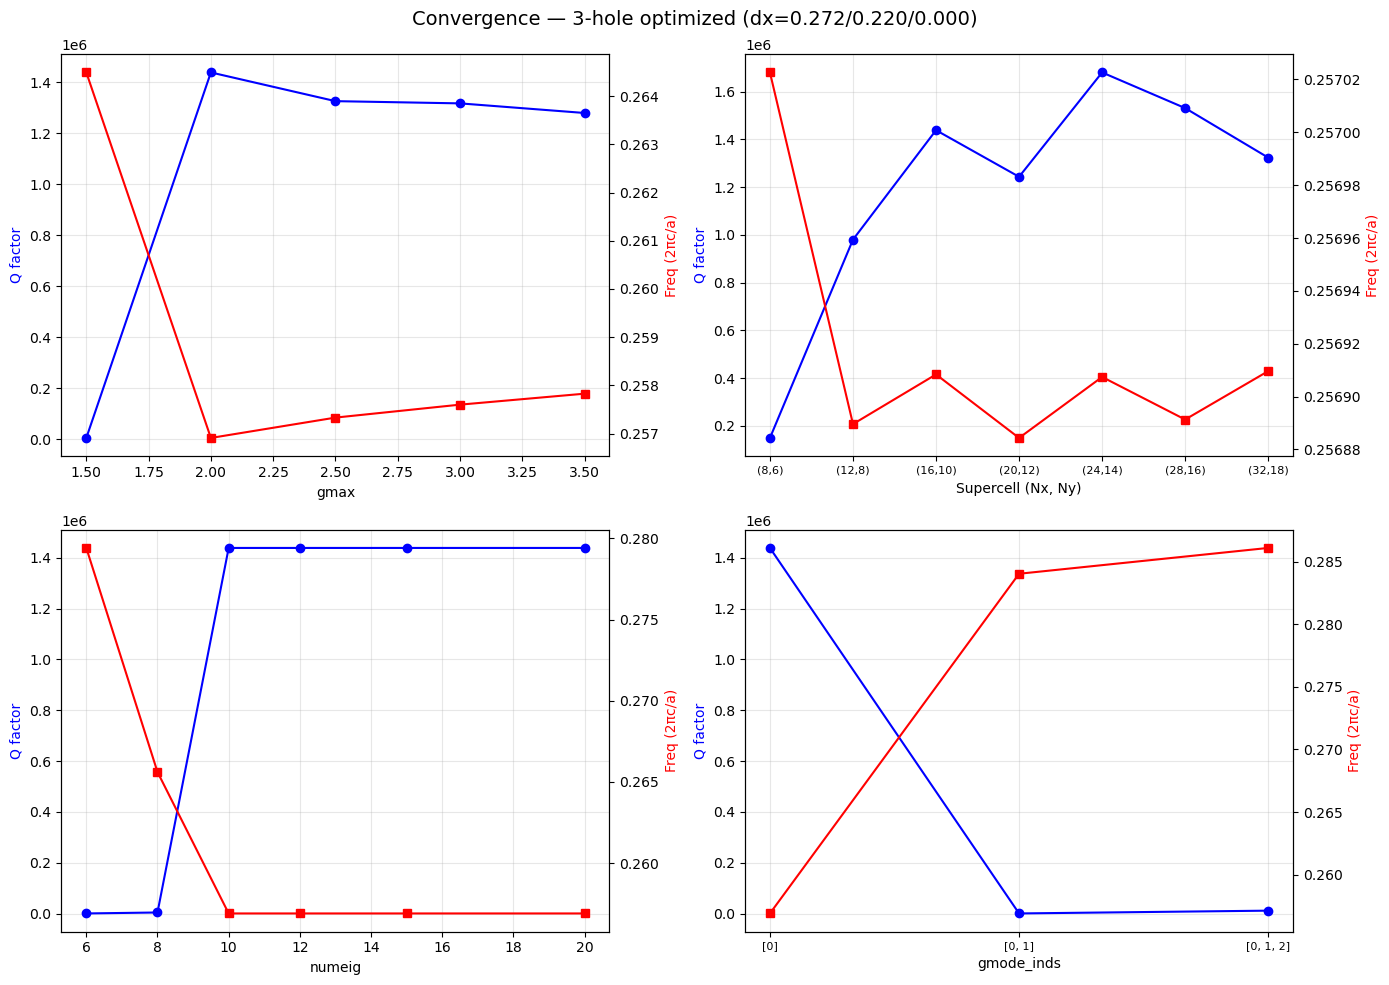


     Parameter      dQ (%)      df (%)    Status
  --------------------------------------------
          gmax        2.86      0.0884        OK
     supercell       13.55      0.0071      WARN
        numeig        0.00      0.0000        OK
    gmode_inds     4919.77      0.7257      WARN


In [ ]:
# --- 3-hole optimized convergence (Q ~ 1,438,926) ---
shifts_3h = [(0, 0.27239), (1, 0.21982), (2, 0.00000)]
run_design_convergence(shifts_3h, "3-hole optimized (dx=0.272/0.220/0.000)")


## Autograd backend

In [12]:
# To compute gradients, we need to set the `legume` backend to 'autograd'
legume.set_backend('autograd')

# Set GME options — use eig_sigma so the solver targets modes near the bandgap centre
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Define an objective function: only optimize the symmetric x-shift of the two end holes
# (ic=0, xp=2.0, yp=0) — Akahane et al. end-hole shift
def of_Q(params):
    # params[0] = x-shift of the two end holes adjacent to the L3 cavity
    dx_full = npa.concatenate([params[0:1], npa.zeros(nc - 1)])
    dy_full = npa.zeros(nc)
    (gme, Q) = gme_cavity(dx_full, dy_full, gmax=gmax, truncate_g=truncate_g, options=options)

    # We put a negative sign because we use in-built methods to *minimize* the objective function
    return -Q

## Test gradient of quality factor

In [13]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_Q)

# We do the numerical check w.r.t. the end-hole shift (the only parameter)
ind0 = 0
# We set the starting parameter to zero, i.e. un-modified cavity
pstart = np.zeros((1,))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1]
# Print the gradient w.r.t. the parameter index ind0
print("Autograd gradient:  %1.4f, computed in %1.4fs" %(grad_a[ind0], time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_Q(p_test) - of_Q(pstart))/1e-5
print("Numerical gradient: %1.4f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a[ind0] - grad_n)/grad_n))


Autograd gradient:  -51749.0330, computed in 21.8006s


KeyboardInterrupt: 

## test gradient of fields

In [ ]:
# Define an objective function which is proportional to the V of the fundamental mode
def of_V(params):
    dx = params[0:nc]
    dy = params[nc:]
    (gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)

    # Get the electric field in the center of the slab
    Ey = gme.get_field_xy('e', kind=0, mind=mode_idx, z=dslab/2, component='y', Nx=3, Ny=3)[0]['y']

    # Notice the use of autograd.numpy (npa) and not plain numpy (np)
    return 1/npa.square(npa.amax(npa.abs(Ey)))


In [ ]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_V)

# We do the numerical check w.r.t. the closest hole to the center
ind0 = 0
# We set the starting parameters to zeros, i.e. un-modified cavity
pstart = np.zeros((2*nc, ))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1][ind0]
print("Autograd gradient:  %1.8f, computed in %1.4fs" %(grad_a, time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_V(p_test) - of_V(pstart))/1e-5
print("Numerical gradient: %1.8f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a - grad_n)/grad_n))

/home/jonah/miniconda3/envs/photonics/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  return onp.asarray(out, dtype=A_dtype)


Autograd gradient:  16.37230575, computed in 19.5436s
Numerical gradient: 16.37243750, computed in 28.4357s
Relative difference: 8.05e-06


## Q factor optimization

In [ ]:
# Initialize an optimization object
opt = Minimize(of_Q)

# Starting parameter
pstart = np.array([0.175])

# Run an 'adam' optimization
(p_opt, ofs) = opt.adam(pstart, step_size=0.02, Nepochs=20, bounds=[0, 0.25])

Epoch:    1/  20 | Duration:  16.27 secs | Objective: -1.891430e+05
Epoch:    2/  20 | Duration:  14.54 secs | Objective: -1.086461e+05
Epoch:    3/  20 | Duration:  15.50 secs | Objective: -1.525220e+05
Epoch:    4/  20 | Duration:  15.50 secs | Objective: -1.960443e+05
Epoch:    5/  20 | Duration:  15.71 secs | Objective: -1.615270e+05
Epoch:    6/  20 | Duration:  14.82 secs | Objective: -1.602149e+05
Epoch:    7/  20 | Duration:  17.14 secs | Objective: -1.844619e+05
Epoch:    8/  20 | Duration:  15.31 secs | Objective: -1.977851e+05
Epoch:    9/  20 | Duration:  15.10 secs | Objective: -1.773841e+05
Epoch:   10/  20 | Duration:  15.38 secs | Objective: -1.756710e+05
Epoch:   11/  20 | Duration:  15.82 secs | Objective: -1.929353e+05
Epoch:   12/  20 | Duration:  15.47 secs | Objective: -1.974151e+05
Epoch:   13/  20 | Duration:  19.56 secs | Objective: -1.860895e+05
Epoch:   14/  20 | Duration:  16.51 secs | Objective: -1.832314e+05
Epoch:   15/  20 | Duration:  17.98 secs | Objec

Cavity quality factor: 198851.54
Optimized end-hole shift: dx[0] = 0.17964a


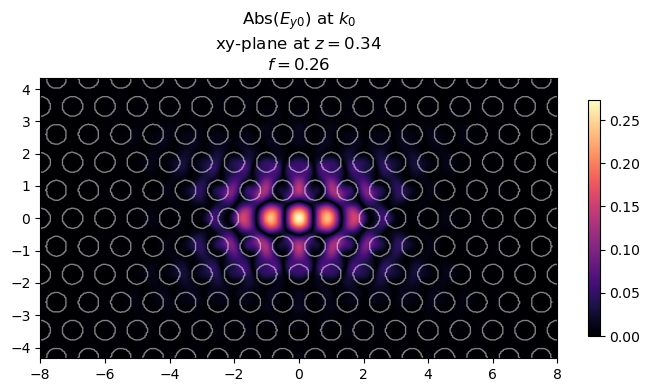

In [38]:
# Optimized parameters — end-hole shift only
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = float(p_opt[0])

# Run the simulation
(gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)
print("Cavity quality factor: %1.2f" % Q)
print(f"Optimized end-hole shift: dx[0] = {float(p_opt[0]):.5f}a")
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=400, N2=400)

In [ ]:
# Save single-hole optimization results
if SAVE_DATA:
    save_sweep('L3_opt_1hole', {
        'p_opt': np.array(p_opt),
        'ofs': np.array(ofs),
        'Q': np.array([Q]),
        'freq': np.array([gme.freqs[0, mode_idx]]),
    }, optimization='1-hole end shift',
       Nepochs=20, step_size=0.02,
       dx0_opt=float(p_opt[0]),
       Q_final=f'{Q:.2f}')

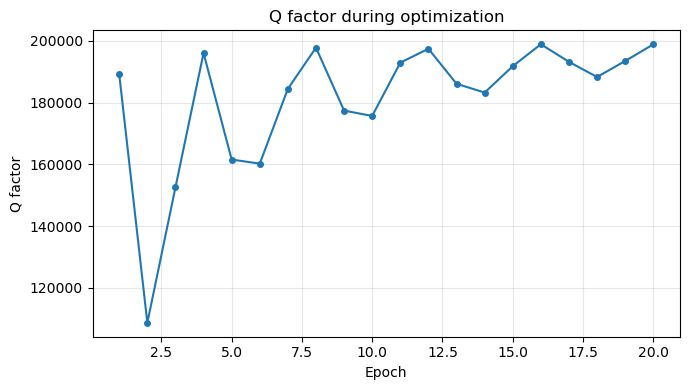

In [39]:
# Plot Q vs optimization epoch (from the ofs array returned by opt.adam)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ofs) + 1), -np.array(ofs), 'o-', lw=1.5, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Q factor')
ax.set_title('Q factor during optimization')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sweeping end-hole shift from 0 to optimized value:
  shift = 0.0000a,  Q = 6343.7
  shift = 0.0128a,  Q = 7063.4
  shift = 0.0257a,  Q = 7915.3
  shift = 0.0385a,  Q = 8940.4
  shift = 0.0513a,  Q = 10198.9
  shift = 0.0642a,  Q = 11781.5
  shift = 0.0770a,  Q = 13831.0
  shift = 0.0898a,  Q = 16582.4
  shift = 0.1027a,  Q = 20444.9
  shift = 0.1155a,  Q = 26181.1
  shift = 0.1283a,  Q = 35332.9
  shift = 0.1411a,  Q = 51315.8
  shift = 0.1540a,  Q = 82191.6
  shift = 0.1668a,  Q = 142825.8
  shift = 0.1796a,  Q = 198852.0


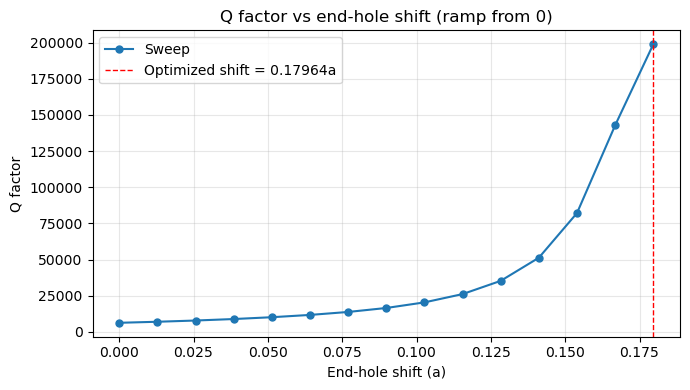

In [12]:
# Parameter sweep: Q vs end-hole shift (ramp from 0 to optimized value)
# Uses numpy backend for speed (no gradient overhead)
legume.set_backend('numpy')

p_opt_shift = 0.17964  # optimized end-hole shift
shifts = np.linspace(0, p_opt_shift, 15)
Qs_sweep = []
options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

print("Sweeping end-hole shift from 0 to optimized value:")
for s in shifts:
    dx_s = np.zeros(nc); dx_s[0] = s
    dy_s = np.zeros(nc)
    (_, Q_s) = gme_cavity(dx_s, dy_s, gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_sweep.append(Q_s)
    print(f"  shift = {s:.4f}a,  Q = {Q_s:.1f}")

# Plot Q vs shift, mark the optimizer result
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, Qs_sweep, 'o-', lw=1.5, markersize=5, label='Sweep')
ax.axvline(p_opt_shift, color='red', ls='--', lw=1,
           label=f'Optimized shift = {p_opt_shift:.5f}a')
ax.set_xlabel('End-hole shift (a)')
ax.set_ylabel('Q factor')
ax.set_title('Q factor vs end-hole shift (ramp from 0)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q factor optimization — 3 nearest-neighbor shifts
Optimize the x-shifts of the 3 closest holes on each side of the L3 cavity (ic=0,1,2 at xp=2,3,4) to maximize Q.

In [33]:
# Switch to autograd backend for gradient-based optimization
legume.set_backend('autograd')

gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Track the best parameters seen during optimization
best_tracker_3h = {'Q': 0, 'params': None}

def _extract_val_3h(x):
    """Extract raw float from autograd ArrayBox or regular number."""
    return float(x._value) if hasattr(x, '_value') else float(x)

# Objective function: optimize x-shifts of the 3 nearest holes on each side
# ic=0 -> xp=2.0 (1st neighbor), ic=1 -> xp=3.0 (2nd), ic=2 -> xp=4.0 (3rd)
def of_Q_3hole(params):
    dx_full = npa.concatenate([params[0:3], npa.zeros(nc - 3)])
    dy_full = npa.zeros(nc)
    (gme, Q) = gme_cavity(dx_full, dy_full, gmax=gmax, truncate_g=truncate_g, options=options)

    # Track best parameters seen
    Q_val = _extract_val_3h(Q)
    if Q_val > best_tracker_3h['Q']:
        best_tracker_3h['Q'] = Q_val
        best_tracker_3h['params'] = np.array([_extract_val_3h(p) for p in params])

    return -Q

# Initialize: seed 1st hole near single-hole optimum, others near zero
opt_3h = Minimize(of_Q_3hole)
pstart_3h = np.array([0.27, 0.21, -0.03])

(p_opt_3h, ofs_3h) = opt_3h.adam(pstart_3h, step_size=0.01, Nepochs=40, bounds=[-0.3, 0.3])

print(f'\nBest Q seen during optimization: {best_tracker_3h["Q"]:.0f}')


Epoch:    1/  40 | Duration:  12.68 secs | Objective: -1.473962e+06
Epoch:    2/  40 | Duration:  18.16 secs | Objective: -6.775388e+05
Epoch:    3/  40 | Duration:  16.49 secs | Objective: -1.171527e+06
Epoch:    4/  40 | Duration:  16.26 secs | Objective: -1.220074e+06
Epoch:    5/  40 | Duration:  15.48 secs | Objective: -1.164057e+06
Epoch:    6/  40 | Duration:  16.98 secs | Objective: -1.391045e+06
Epoch:    7/  40 | Duration:  15.53 secs | Objective: -1.339606e+06
Epoch:    8/  40 | Duration:  16.53 secs | Objective: -1.296464e+06
Epoch:    9/  40 | Duration:  14.85 secs | Objective: -1.333197e+06
Epoch:   10/  40 | Duration:  17.30 secs | Objective: -1.444201e+06
Epoch:   11/  40 | Duration:  16.85 secs | Objective: -1.405904e+06
Epoch:   12/  40 | Duration:  17.24 secs | Objective: -1.358007e+06
Epoch:   13/  40 | Duration:  14.75 secs | Objective: -1.392660e+06
Epoch:   14/  40 | Duration:  18.34 secs | Objective: -1.420736e+06
Epoch:   15/  40 | Duration:  15.07 secs | Objec

3-hole optimized Q factor: 1481711.59
  Hole 1 shift (xp=2): dx = 0.26896a  (67.24 nm)
  Hole 2 shift (xp=3): dx = 0.20837a  (52.09 nm)
  Hole 3 shift (xp=4): dx = -0.03873a  (-9.68 nm)

Comparison: single-hole Q = 6343.69 -> 3-hole Q = 1481711.59  (x233.6 improvement)


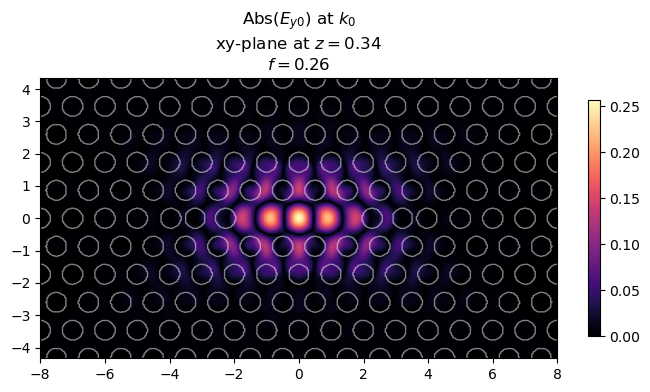

In [34]:
# Use the BEST parameters seen during optimization, not the final epoch
p_best_3h = best_tracker_3h['params'] if best_tracker_3h['params'] is not None else np.array([float(p) for p in p_opt_3h])

dx_3h = np.zeros(nc)
dy_3h = np.zeros(nc)
dx_3h[0] = p_best_3h[0]
dx_3h[1] = p_best_3h[1]
dx_3h[2] = p_best_3h[2]

(gme_3h, Q_3h) = gme_cavity(dx_3h, dy_3h, gmax=gmax, truncate_g=truncate_g, options=options)

print(f"3-hole optimized Q factor: {Q_3h:.2f}")
print(f"  Hole 1 shift (xp=2): dx = {p_best_3h[0]:.5f}a  ({p_best_3h[0]*a_nm:.2f} nm)")
print(f"  Hole 2 shift (xp=3): dx = {p_best_3h[1]:.5f}a  ({p_best_3h[1]*a_nm:.2f} nm)")
print(f"  Hole 3 shift (xp=4): dx = {p_best_3h[2]:.5f}a  ({p_best_3h[2]*a_nm:.2f} nm)")
print(f"\nComparison: single-hole Q = {Q:.2f} -> 3-hole Q = {Q_3h:.2f}  (x{Q_3h/Q:.1f} improvement)")

ax = legume.viz.field(gme_3h, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=400, N2=400)


In [35]:
# Save 3-hole optimization results
if SAVE_DATA:
    save_sweep('L3_opt_3hole', {
        'p_opt': np.array(p_opt_3h),
        'ofs': np.array(ofs_3h),
        'Q': np.array([Q_3h]),
        'freq': np.array([gme_3h.freqs[0, mode_idx]]),
    }, optimization='3-hole nearest-neighbor shifts',
       Nepochs=30, step_size=0.02,
       dx0_opt=float(p_opt_3h[0]),
       dx1_opt=float(p_opt_3h[1]),
       dx2_opt=float(p_opt_3h[2]),
       Q_final=f'{Q_3h:.2f}')

Results saved to data/2026-04-08_181614_L3_opt_3hole/


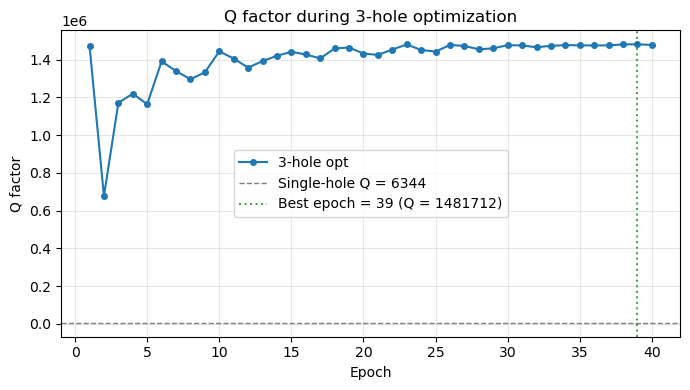

In [36]:
# Plot Q vs epoch for 3-hole optimization
Q_traj_3h = -np.array(ofs_3h)
best_epoch_3h = np.argmax(Q_traj_3h) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ofs_3h) + 1), Q_traj_3h, 'o-', lw=1.5, markersize=4, label='3-hole opt')
ax.axhline(Q, color='gray', ls='--', lw=1, label=f'Single-hole Q = {Q:.0f}')
ax.axvline(best_epoch_3h, color='green', ls=':', lw=1.5, alpha=0.7,
           label=f'Best epoch = {best_epoch_3h} (Q = {np.max(Q_traj_3h):.0f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Q factor')
ax.set_title('Q factor during 3-hole optimization')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Phase 1: ramping dx[0] (nearest hole), dx[1] = 0
   dx[0] (a)   dx[1] (a)               Q        freq
  ------------------------------------------------
     0.00000     0.00000          6343.7
     0.00939     0.00000          6858.9
     0.01879     0.00000          7440.1
     0.02818     0.00000          8101.0
     0.03757     0.00000          8859.7
     0.04696     0.00000          9740.1
     0.05636     0.00000         10774.3
     0.06575     0.00000         12006.8
     0.07514     0.00000         13499.7
     0.08453     0.00000         15343.2
     0.09393     0.00000         17671.0
     0.10332     0.00000         20688.6
     0.11271     0.00000         24724.6
     0.12211     0.00000         30327.6
     0.13150     0.00000         38459.8
     0.14089     0.00000         50892.9
     0.15028     0.00000         70985.0
     0.15968     0.00000        104654.6
     0.16907     0.00000        156614.8
     0.17846     0.00000        198443.8
     0.18786     0.00000   

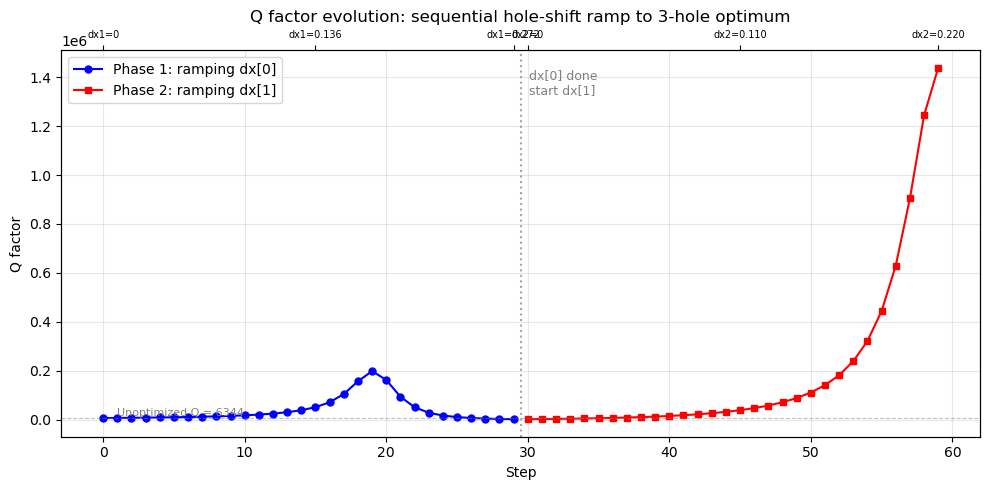

Results saved to data/2026-04-08_184028_sequential_hole_ramp/

Summary:
  Unoptimized:        Q = 6344
  After dx[0] ramp:   Q = 2031  (dx[0] = 0.27239a)
  After dx[1] ramp:   Q = 1438926  (dx[1] = 0.21982a)
  Peak during phase 1: Q = 198444  at dx[0] = 0.17846a


In [ ]:
# Sequential hole-shift sweep: ramp dx[0] then dx[1] to optimized values
# Shows individual contribution of each hole shift to Q factor
legume.set_backend('numpy')

dx1_target = 0.27239   # optimized dx[0] (nearest hole, xp=2)
dx2_target = 0.21982   # optimized dx[1] (2nd nearest, xp=3)
N_steps = 30

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

# --- Phase 1: ramp dx[0] from 0 to target, dx[1] = 0 ---
dx1_vals = np.linspace(0, dx1_target, N_steps)
Qs_p1, freqs_p1 = [], []

print("Phase 1: ramping dx[0] (nearest hole), dx[1] = 0")
print(f"  {'dx[0] (a)':>10s}  {'dx[1] (a)':>10s}  {'Q':>14s}  {'freq':>10s}")
print("  " + "-" * 48)
for dx1 in dx1_vals:
    dx_s = np.zeros(nc); dx_s[0] = dx1
    (_, Q_s) = gme_cavity(dx_s, np.zeros(nc), gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_p1.append(Q_s)
    print(f"  {dx1:10.5f}  {0:10.5f}  {Q_s:14.1f}")

# --- Phase 2: hold dx[0] = target, ramp dx[1] from 0 to target ---
dx2_vals = np.linspace(0, dx2_target, N_steps)
Qs_p2, freqs_p2 = [], []

print(f"\nPhase 2: dx[0] = {dx1_target}, ramping dx[1] (2nd nearest hole)")
print(f"  {'dx[0] (a)':>10s}  {'dx[1] (a)':>10s}  {'Q':>14s}")
print("  " + "-" * 38)
for dx2 in dx2_vals:
    dx_s = np.zeros(nc); dx_s[0] = dx1_target; dx_s[1] = dx2
    (_, Q_s) = gme_cavity(dx_s, np.zeros(nc), gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_p2.append(Q_s)
    print(f"  {dx1_target:10.5f}  {dx2:10.5f}  {Q_s:14.1f}")

# --- Figure 1: Sequential phases combined plot ---
Qs_all = Qs_p1 + Qs_p2
steps = np.arange(len(Qs_all))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps[:N_steps], Qs_p1, 'bo-', lw=1.5, ms=5, label='Phase 1: ramping dx[0]')
ax.plot(steps[N_steps:], Qs_p2, 'rs-', lw=1.5, ms=5, label='Phase 2: ramping dx[1]')
ax.axvline(N_steps - 0.5, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(N_steps - 0.5, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else max(Qs_all) * 0.95,
        '  dx[0] done\n  start dx[1]', fontsize=9, color='gray', va='top')

# Mark key Q values
ax.axhline(Qs_p1[0], color='gray', ls='--', lw=0.8, alpha=0.5)
ax.text(0.5, Qs_p1[0], f'  Unoptimized Q = {Qs_p1[0]:.0f}', fontsize=8, va='bottom', color='gray')

ax.set_xlabel('Step')
ax.set_ylabel('Q factor')
ax.set_title('Q factor evolution: sequential hole-shift ramp to 1-hole optimum')

# Add secondary x-axis labels showing shift values
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_pos = [0, N_steps//2, N_steps-1, N_steps, N_steps + N_steps//2, 2*N_steps-1]
tick_labels = [
    f'dx1=0', f'dx1={dx1_target/2:.3f}', f'dx1={dx1_target:.3f}',
    f'dx2=0', f'dx2={dx2_target/2:.3f}', f'dx2={dx2_target:.3f}'
]
ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_labels, fontsize=7)

ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Simultaneous ramp: dx[0] and dx[1] scaled proportionally to target
       t   dx[0] (a)   dx[1] (a)               Q
  ----------------------------------------------
   0.000     0.00000     0.00000          6343.7
   0.034     0.00939     0.00758          6796.0
   0.069     0.01879     0.01516          7295.9
   0.103     0.02818     0.02274          7850.4
   0.138     0.03757     0.03032          8467.8
   0.172     0.04696     0.03790          9158.3
   0.207     0.05636     0.04548          9934.2
   0.241     0.06575     0.05306         10811.0
   0.276     0.07514     0.06064         11807.6
   0.310     0.08453     0.06822         12948.2
   0.345     0.09393     0.07580         14263.0
   0.379     0.10332     0.08338         15791.3
   0.414     0.11271     0.09096         17583.6
   0.448     0.12211     0.09854         19706.5
   0.483     0.13150     0.10612         22248.6
   0.517     0.14089     0.11370         25329.4
   0.552     0.15028     0.12128         29113.3
  

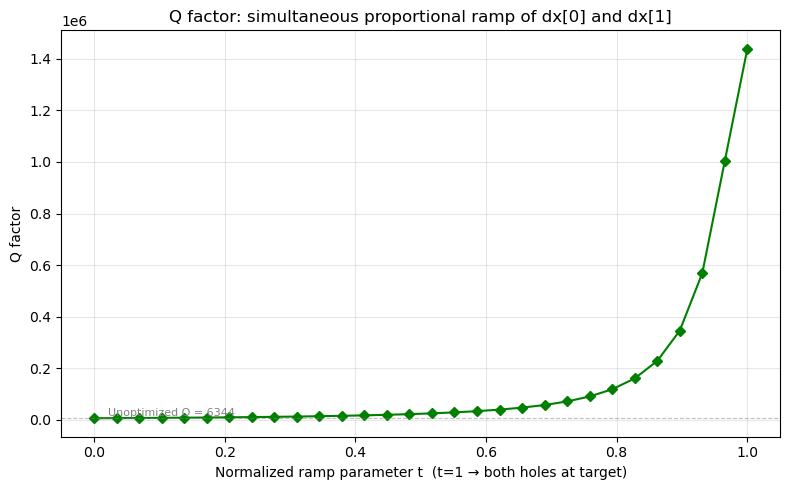

Results saved to data/2026-04-14_104125_simultaneous_hole_ramp/

Summary:
  Unoptimized (t=0):   Q = 6344
  Optimized (t=1):     Q = 1438926  (dx[0]=0.27239a, dx[1]=0.21982a)
  Peak:                Q = 1438926  at t = 1.000


In [29]:
# Simultaneous hole-shift sweep: ramp dx[0] and dx[1] proportionally to optimized values
legume.set_backend('numpy')

dx1_target = 0.27239   # optimized dx[0] (nearest hole, xp=2)
dx2_target = 0.21982   # optimized dx[1] (2nd nearest, xp=3)
N_steps = 30

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

t_vals = np.linspace(0, 1, N_steps)
Qs_p3 = []

print("Simultaneous ramp: dx[0] and dx[1] scaled proportionally to target")
print(f"  {'t':>6s}  {'dx[0] (a)':>10s}  {'dx[1] (a)':>10s}  {'Q':>14s}")
print("  " + "-" * 46)
for t in t_vals:
    dx_s = np.zeros(nc)
    dx_s[0] = t * dx1_target
    dx_s[1] = t * dx2_target
    (_, Q_s) = gme_cavity(dx_s, np.zeros(nc), gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_p3.append(Q_s)
    print(f"  {t:6.3f}  {dx_s[0]:10.5f}  {dx_s[1]:10.5f}  {Q_s:14.1f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_vals, Qs_p3, 'gD-', lw=1.5, ms=5)
ax.axhline(Qs_p3[0], color='gray', ls='--', lw=0.8, alpha=0.5)
ax.text(0.01, Qs_p3[0], f'  Unoptimized Q = {Qs_p3[0]:.0f}', fontsize=8, va='bottom', color='gray')
ax.set_xlabel('Normalized ramp parameter t  (t=1 → both holes at target)')
ax.set_ylabel('Q factor')
ax.set_title('Q factor: simultaneous proportional ramp of dx[0] and dx[1]')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Save results ---
if SAVE_DATA:
    save_sweep('simultaneous_hole_ramp', {
        't_vals': t_vals,
        'Qs': np.array(Qs_p3),
    }, dx1_target=dx1_target, dx2_target=dx2_target, N_steps=N_steps)

print(f"\nSummary:")
print(f"  Unoptimized (t=0):   Q = {Qs_p3[0]:.0f}")
print(f"  Optimized (t=1):     Q = {Qs_p3[-1]:.0f}  (dx[0]={dx1_target:.5f}a, dx[1]={dx2_target:.5f}a)")
print(f"  Peak:                Q = {max(Qs_p3):.0f}  at t = {t_vals[np.argmax(Qs_p3)]:.3f}")


Curvy sweep
      t   dx[0] (a)   dx[1] (a)               Q
  ----------------------------------------------
   0.00     0.13000     0.00000         36933.6
   0.17     0.13833     0.00000         46928.6
   0.33     0.14667     0.00000         62025.5
   0.50     0.15500     0.00000         85726.3
   0.67     0.16333     0.00000        122893.5
   0.83     0.17167     0.00000        172206.7
   1.00     0.18000     0.00000        198664.7
   1.00     0.18000     0.00000        198664.7
   1.11     0.18000     0.03333        147856.0
   1.22     0.18000     0.06667         92116.7
   1.33     0.18000     0.10000         65638.6
   1.44     0.18000     0.13333         52170.8
   1.56     0.18000     0.16667         44719.1
   1.67     0.18000     0.20000         40589.9
   1.78     0.18000     0.23333          1237.8
   1.89     0.18000     0.26667          1025.9
   2.00     0.18000     0.30000           788.8
   2.00     0.18000     0.30000           788.8
   2.14     0.19314     0.2

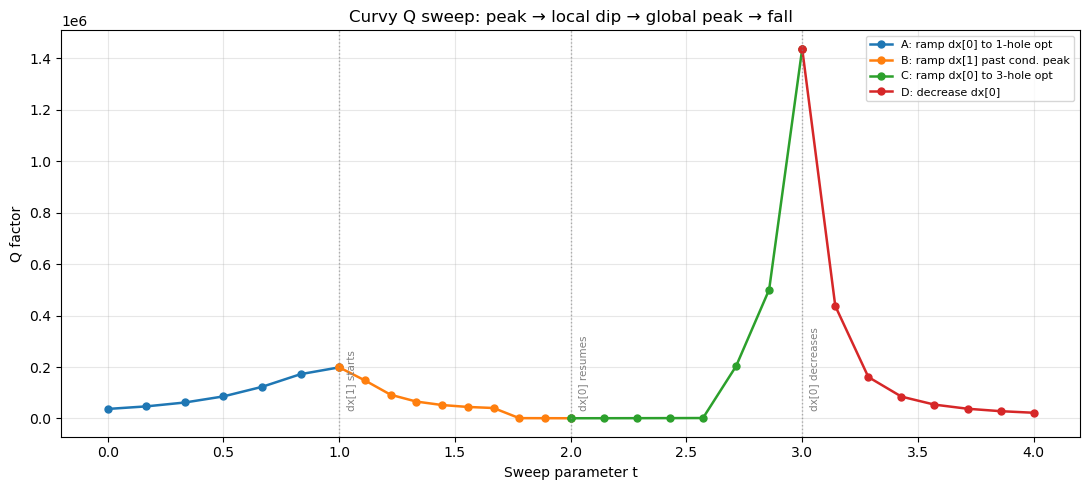

Results saved to data/2026-04-14_134810_curvy_sweep/


In [38]:
# Curvy Q sweep: 4-phase continuous path through (dx[0], dx[1]) space
#
# Phase A (t: 0→1): dx[0]: 0.13→0.18,  dx[1]=0           → rise to 1-hole peak
# Phase B (t: 1→2): dx[0]=0.18,         dx[1]: 0→0.30     → rise past conditional peak, then dip
# Phase C (t: 2→3): dx[0]: 0.18→0.272,  dx[1]: 0.30→0.22  → recover toward 3-hole peak
# Phase D (t: 3→4): dx[0]: 0.272→0.14,  dx[1]=0.22        → fall off
legume.set_backend('numpy')

Na, Nb, Nc, Nd = 7, 10, 8, 8   # steps per phase → 33 sims (~9 min)

dx0_path = np.concatenate([
    np.linspace(0.13,   0.18,   Na),
    np.full(Nb,         0.18),
    np.linspace(0.18,   0.272,  Nc),
    np.linspace(0.272,  0.14,   Nd),
])
dx1_path = np.concatenate([
    np.zeros(Na),
    np.linspace(0,     0.30,   Nb),
    np.linspace(0.30,  0.22,   Nc),
    np.full(Nd,        0.22),
])
t_path = np.concatenate([
    np.linspace(0, 1, Na),
    np.linspace(1, 2, Nb),
    np.linspace(2, 3, Nc),
    np.linspace(3, 4, Nd),
])

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

Qs_curvy = []
print("Curvy sweep")
print(f"  {'t':>5s}  {'dx[0] (a)':>10s}  {'dx[1] (a)':>10s}  {'Q':>14s}")
print("  " + "-" * 46)
for t, dx0, dx1 in zip(t_path, dx0_path, dx1_path):
    dx_s = np.zeros(nc)
    dx_s[0] = dx0
    dx_s[1] = dx1
    (_, Q_s) = gme_cavity(dx_s, np.zeros(nc), gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_curvy.append(Q_s)
    print(f"  {t:5.2f}  {dx0:10.5f}  {dx1:10.5f}  {Q_s:14.1f}")

Qs_curvy = np.array(Qs_curvy)
Na, Nb, Nc, Nd = 7, 10, 8, 8

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = ['A: ramp dx[0] to 1-hole opt', 'B: ramp dx[1] past cond. peak',
          'C: ramp dx[0] to 3-hole opt', 'D: decrease dx[0]']
slices = [
    slice(0,         Na),
    slice(Na-1,      Na+Nb),
    slice(Na+Nb-1,   Na+Nb+Nc),
    slice(Na+Nb+Nc-1, None),
]
for sl, color, label in zip(slices, colors, labels):
    ax.plot(t_path[sl], Qs_curvy[sl], 'o-', color=color, lw=1.8, ms=5, label=label)

for tv, lbl in [(1, 'dx[1] starts'), (2, 'dx[0] resumes'), (3, 'dx[0] decreases')]:
    ax.axvline(tv, color='gray', ls=':', lw=1, alpha=0.6)
    ax.text(tv + 0.03, ax.get_ylim()[1] * 0.02, lbl, fontsize=7.5, color='gray', rotation=90, va='bottom')

ax.set_xlabel('Sweep parameter t')
ax.set_ylabel('Q factor')
ax.set_title('Curvy Q sweep: peak → local dip → global peak → fall')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Save ---
if SAVE_DATA:
    save_sweep('curvy_sweep', {
        't_path':   t_path,
        'dx0_path': dx0_path,
        'dx1_path': dx1_path,
        'Qs':       Qs_curvy,
    }, Na=Na, Nb=Nb, Nc=Nc, Nd=Nd)


## Q factor optimization — 4 x-neighbors + 2 adjacent rows
Optimize the x-shifts of 4 nearest holes along the cavity axis **plus** dx/dy shifts
of the first two rows above and below the cavity (6 holes in row 1, 5 in row 2).
All shifts are applied symmetrically via the existing `cavity()` function.

**16 parameters total:**
- `params[0:4]` → dx for row 0 (ic=0,1,2,3 at xp=2,3,4,5)
- `params[4:7]` → dx for row 1 (ic=7,8,9 at xp=0.5,1.5,2.5)
- `params[7:10]` → dy for row 1
- `params[10:13]` → dx for row 2 (ic=16,17,18 at xp=0,1,2)
- `params[13:16]` → dy for row 2

In [21]:
# Switch to autograd backend for gradient-based optimization
legume.set_backend('autograd')

gmax = 2
truncate_g = 'tbt'

# Track the best parameters seen during optimization
# (adam returns the LAST epoch, not the best — this captures the peak)
best_tracker = {'Q': 0, 'params': None}

def _extract_val(x):
    """Extract raw float from autograd ArrayBox or regular number."""
    return float(x._value) if hasattr(x, '_value') else float(x)

# Robust objective function: re-identifies the cavity mode each evaluation
#
# 15 parameters:
#   [0:4]   row 0 dx (ic=0,1,2,3 at xp=2,3,4,5)
#   [4:7]   row 1 dx (ic=7,8,9 at xp=0.5,1.5,2.5)
#   [7:10]  row 1 dy (ic=7,8,9)
#   [10:12] row 2 dx (ic=17,18 at xp=1,2) — ic=16 (xp=0) is on symmetry axis, fixed
#   [12:15] row 2 dy (ic=16,17,18)
def of_Q_extended(params):
    # dx_full: ic=16 (xp=0, on symmetry axis) gets no dx shift
    dx_full = npa.concatenate([
        params[0:4],          # ic=0-3: row 0 dx
        npa.zeros(3),         # ic=4-6: far row 0 (unshifted)
        params[4:7],          # ic=7-9: row 1 dx
        npa.zeros(6),         # ic=10-15: far row 1 (unshifted)
        npa.zeros(1),         # ic=16: row 2, xp=0 (symmetry axis — no dx)
        params[10:12],        # ic=17-18: row 2 dx
        npa.zeros(nc - 19),   # ic=19+: everything else
    ])
    # dy_full: all 3 row-2 holes can shift in y (including ic=16)
    dy_full = npa.concatenate([
        npa.zeros(7),         # ic=0-6: row 0 (no dy)
        params[7:10],         # ic=7-9: row 1 dy
        npa.zeros(6),         # ic=10-15: far row 1 (unshifted)
        params[12:15],        # ic=16-18: row 2 dy
        npa.zeros(nc - 19),   # ic=19+: everything else
    ])

    # Build and solve the cavity
    phc = cavity(dx_full, dy_full)
    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)
    gme.run(kpoints=np.array([[0], [0]]), gmode_inds=[0], verbose=False,
            numeig=10, eig_sigma=f_target, gradients='approx', compute_im=False)

    # Re-identify the cavity mode: find highest-Q mode inside the bandgap
    best_Q = npa.array(-1.0)
    best_idx = mode_idx  # fallback
    for i in range(gme.freqs.shape[1]):
        if f_lb < gme.freqs[0, i] < f_ub:
            (fim, _, _) = gme.compute_rad(0, [i])
            Qi = gme.freqs[0, i] / (2 * fim[0])
            if Qi > best_Q:
                best_Q = Qi
                best_idx = i

    # If no mode in bandgap, return penalty so optimizer retreats
    if best_Q < 0:
        return npa.array(0.0)

    (freq_im, _, _) = gme.compute_rad(0, [best_idx])
    Q = gme.freqs[0, best_idx] / (2 * freq_im[0])

    # Save best parameters seen (_extract_val handles autograd ArrayBox)
    Q_val = _extract_val(Q)
    if Q_val > best_tracker['Q']:
        best_tracker['Q'] = Q_val
        best_tracker['params'] = np.array([_extract_val(p) for p in params])

    return -Q

# Starting values: seed row 0 from known good shifts, rows 1-2 start at zero
pstart_ext = np.array([
    0.27511, 0.23256, -0.00236, 0.12254,       # row 0 dx (ic=0,1,2,3)
    0.00084, 0.00850, 0.00230,              # row 1 dx (ic=7,8,9)
    0.02034, 0.00217, 0.00516,              # row 1 dy (ic=7,8,9)
    -0.00971, -0.01053,                   # row 2 dx (ic=17,18 only — ic=16 fixed by symmetry)
    0.01415, 0.00567, 0.01145,              # row 2 dy (ic=16,17,18)
])

# Smaller step size to prevent overshooting past the Q peak
opt_ext = Minimize(of_Q_extended)
(p_opt_ext, ofs_ext) = opt_ext.adam(pstart_ext, step_size=0.0001, Nepochs=40,
                                    bounds=[-0.3, 0.3])

print(f'\nBest Q seen during optimization: {best_tracker["Q"]:.0f}')

Epoch:    1/  40 | Duration:  19.36 secs | Objective: -4.340595e+07
Epoch:    2/  40 | Duration:  20.00 secs | Objective: -4.063916e+07
Epoch:    3/  40 | Duration:  19.99 secs | Objective: -4.303046e+07
Epoch:    4/  40 | Duration:  19.06 secs | Objective: -4.285686e+07
Epoch:    5/  40 | Duration:  20.65 secs | Objective: -4.199283e+07
Epoch:    6/  40 | Duration:  21.78 secs | Objective: -4.245803e+07
Epoch:    7/  40 | Duration:  19.52 secs | Objective: -4.322546e+07
Epoch:    8/  40 | Duration:  21.00 secs | Objective: -4.346177e+07
Epoch:    9/  40 | Duration:  20.98 secs | Objective: -4.307791e+07
Epoch:   10/  40 | Duration:  22.56 secs | Objective: -4.275945e+07
Epoch:   11/  40 | Duration:  20.24 secs | Objective: -4.292955e+07
Epoch:   12/  40 | Duration:  20.42 secs | Objective: -4.331031e+07
Epoch:   13/  40 | Duration:  20.35 secs | Objective: -4.353038e+07
Epoch:   14/  40 | Duration:  22.58 secs | Objective: -4.344171e+07
Epoch:   15/  40 | Duration:  19.78 secs | Objec

Best Q seen during optimization: 43709608

Extended optimization Q factor: 43709607.60
Single-hole Q factor:           6343.69
Improvement:                    6890.25x

   Row    ic      xp      yp    dx (a)    dy (a)   dx (nm)   dy (nm)
--------------------------------------------------------------------
 Row 0     0     2.0   0.000   0.27487   0.00000      68.7       0.0
 Row 0     1     3.0   0.000   0.23278   0.00000      58.2       0.0
 Row 0     2     4.0   0.000  -0.00241   0.00000      -0.6       0.0
 Row 0     3     5.0   0.000   0.12142   0.00000      30.4       0.0
 Row 1     7     0.5   0.866   0.00094   0.02053       0.2       5.1
 Row 1     8     1.5   0.866   0.00873   0.00237       2.2       0.6
 Row 1     9     2.5   0.866   0.00226   0.00513       0.6       1.3
 Row 2    16     0.0   1.732   0.00000   0.01433       0.0       3.6
 Row 2    17     1.0   1.732  -0.00962   0.00565      -2.4       1.4
 Row 2    18     2.0   1.732  -0.01077   0.01215      -2.7       3.0


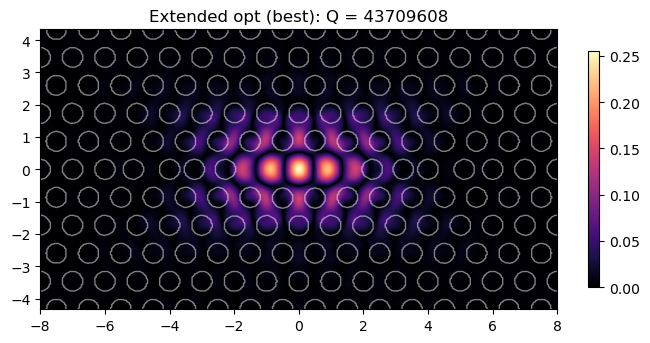

In [22]:
# Use the BEST parameters seen during optimization, not the final epoch
p_best = best_tracker['params']
print(f'Best Q seen during optimization: {best_tracker["Q"]:.0f}')

# Optimized parameters — extended (4 x-neighbors + 2 rows, 15 params)
dx_ext = np.zeros(nc)
dy_ext = np.zeros(nc)

# Row 0 dx
dx_ext[0] = p_best[0]
dx_ext[1] = p_best[1]
dx_ext[2] = p_best[2]
dx_ext[3] = p_best[3]
# Row 1 dx, dy
dx_ext[7] = p_best[4]
dx_ext[8] = p_best[5]
dx_ext[9] = p_best[6]
dy_ext[7] = p_best[7]
dy_ext[8] = p_best[8]
dy_ext[9] = p_best[9]
# Row 2 dx (ic=16 fixed at 0 by symmetry), dy
dx_ext[17] = p_best[10]
dx_ext[18] = p_best[11]
dy_ext[16] = p_best[12]
dy_ext[17] = p_best[13]
dy_ext[18] = p_best[14]

options_ext = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'eig_sigma': f_target, 'gradients': 'approx'}
(gme_ext, Q_ext) = gme_cavity(dx_ext, dy_ext, gmax=gmax, truncate_g=truncate_g, options=options_ext)

# Print results table
print(f'\nExtended optimization Q factor: {Q_ext:.2f}')
print(f'Single-hole Q factor:           {Q:.2f}')
print(f'Improvement:                    {Q_ext/Q:.2f}x\n')

hole_info = [
    ('Row 0', [(0, 2.0, 0.0), (1, 3.0, 0.0), (2, 4.0, 0.0), (3, 5.0, 0.0)]),
    ('Row 1', [(7, 0.5, 0.866), (8, 1.5, 0.866), (9, 2.5, 0.866)]),
    ('Row 2', [(16, 0.0, 1.732), (17, 1.0, 1.732), (18, 2.0, 1.732)]),
]

print(f'{"Row":>6s}  {"ic":>4s}  {"xp":>6s}  {"yp":>6s}  {"dx (a)":>8s}  {"dy (a)":>8s}  {"dx (nm)":>8s}  {"dy (nm)":>8s}')
print('-' * 68)
for row_name, holes in hole_info:
    for ic, xp_v, yp_v in holes:
        dx_v, dy_v = dx_ext[ic], dy_ext[ic]
        print(f'{row_name:>6s}  {ic:4d}  {xp_v:6.1f}  {yp_v:6.3f}  {dx_v:8.5f}  {dy_v:8.5f}  {dx_v*a_nm:8.1f}  {dy_v*a_nm:8.1f}')
    row_name = ''  # only print row name once

# Visualize the mode profile
ax = legume.viz.field(gme_ext, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=400, N2=400)
plt.title(f'Extended opt (best): Q = {Q_ext:.0f}')
plt.show()

In [16]:
# Mode volume comparison — standalone cell (no optimization cells required)
# Hardcoded shifts from optimization results. Only needs mode_idx, cavity(), gme_cavity().
legume.set_backend('numpy')

options_mv = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
              'eig_sigma': f_target, 'gradients': 'approx'}

# --- Define designs ---
designs_raw = [
    {
        'name': 'Unoptimized',
        'Q_ref': 6343.69,
        'dx': {},   # no shifts
        'dy': {},
    },
    {
        'name': '1-hole opt',
        'Q_ref': 198851.54,
        'dx': {0: 0.17964},
        'dy': {},
    },
    {
        'name': '3-hole opt',
        'Q_ref': 1438926.31,
        'dx': {0: 0.27239, 1: 0.21982, 2: 0.00000},
        'dy': {},
    },
    {
        'name': 'Extended (15p)',
        'Q_ref': 43709607.60,
        'dx': {0: 0.27487, 1: 0.23278, 2: -0.00241, 3: 0.12142,
               7: 0.00094, 8: 0.00873, 9: 0.00226,
               17: -0.00962, 18: -0.01077},
        'dy': {7: 0.02053, 8: 0.00237, 9: 0.00513,
               16: 0.01433, 17: 0.00565, 18: 0.01215},
    },
]

results = []

for d in designs_raw:
    print(f"Computing: {d['name']} ...")
    dx_arr = np.zeros(nc);  dy_arr = np.zeros(nc)
    for ic, val in d['dx'].items():
        dx_arr[ic] = val
    for ic, val in d['dy'].items():
        dy_arr[ic] = val

    (gme_d, Q_d) = gme_cavity(dx_arr, dy_arr, gmax=2, truncate_g='tbt', options=options_mv)
    f_cav = float(gme_d.freqs[0, mode_idx])
    V_a3, V_norm = compute_mode_volume(gme_d, mode_idx, f_cav)
    results.append({'name': d['name'], 'Q': d['Q_ref'], 'f': f_cav,
                    'V_a3': V_a3, 'V_norm': V_norm})
    print(f"  Q = {d['Q_ref']:.0f},  V = {V_a3:.4f} a^3  =  {V_norm:.4f} (lam/n)^3,  Q/V = {d['Q_ref']/V_norm:.0f}")

# --- Print comparison table ---
print()
print('=' * 74)
print(f"{'Design':<16} {'Q':>12} {'V (a^3)':>10} {'V (lam/n)^3':>13} {'Q/V':>14}")
print('-' * 74)
for r in results:
    QoV = r['Q'] / r['V_norm']
    lam_nm = a_nm / r['f']
    print(f"{r['name']:<16} {r['Q']:>12.0f} {r['V_a3']:>10.4f} {r['V_norm']:>13.4f} {QoV:>14.0f}")
print('=' * 74)
print(f"  lambda (unopt) = {a_nm / results[0]['f']:.1f} nm  (a = {a_nm} nm)")


Computing: Unoptimized ...
  Q = 6344,  V = 0.9255 a^3  =  0.6711 (lam/n)^3,  Q/V = 9453
Computing: 1-hole opt ...
  Q = 198852,  V = 1.1835 a^3  =  0.8374 (lam/n)^3,  Q/V = 237457
Computing: 3-hole opt ...
  Q = 1438926,  V = 1.3467 a^3  =  0.9459 (lam/n)^3,  Q/V = 1521239
Computing: Extended (15p) ...
  Q = 43709608,  V = 1.3567 a^3  =  0.9375 (lam/n)^3,  Q/V = 46623356

Design                      Q    V (a^3)   V (lam/n)^3            Q/V
--------------------------------------------------------------------------
Unoptimized              6344     0.9255        0.6711           9453
1-hole opt             198852     1.1835        0.8374         237457
3-hole opt            1438926     1.3467        0.9459        1521239
Extended (15p)       43709608     1.3567        0.9375       46623356
  lambda (unopt) = 962.8 nm  (a = 250 nm)


In [21]:
# Save extended optimization results
if SAVE_DATA:
    save_sweep('L3_opt_extended', {
        'p_opt': np.array(p_opt_ext),
        'ofs': np.array(ofs_ext),
        'Q': np.array([Q_ext]),
        'freq': np.array([gme_ext.freqs[0, mode_idx]]),
        'dx_ext': dx_ext,
        'dy_ext': dy_ext,
    }, num_params=16,
       row0_dx='ic=0,1,2,3',
       row1_dx='ic=7,8,9', row1_dy='ic=7,8,9',
       row2_dx='ic=16,17,18', row2_dy='ic=16,17,18',
       step_size=0.005, Nepochs=100, bounds='[-0.25, 0.25]')

Results saved to data/2026-03-24_155014_L3_opt_extended/


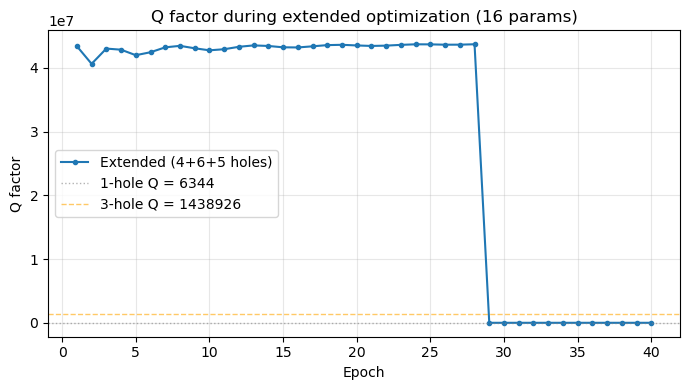

In [23]:
# Plot Q vs epoch for extended optimization
Q_3h = 1438926


fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ofs_ext) + 1), -np.array(ofs_ext), 'o-', lw=1.5, markersize=3,
        label='Extended (4+6+5 holes)')
ax.axhline(Q, color='gray', ls=':', lw=1, alpha=0.6, label=f'1-hole Q = {Q:.0f}')
ax.axhline(Q_3h, color='orange', ls='--', lw=1, alpha=0.6, label=f'3-hole Q = {Q_3h:.0f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Q factor')
ax.set_title('Q factor during extended optimization (16 params)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Seeded f_prev = 0.256908 from mode_idx=0 at t=0

Extended ramp: 3-hole opt → extended optimum → overshoot
      t   mind        freq               Q
  ----------------------------------------
   0.00      8    0.256908       1438926.2
   0.07      8    0.256811       1623101.9
   0.13      8    0.256713       1845943.6
   0.20      8    0.256617       2119354.8
   0.27      8    0.256522       2460197.2
   0.33      8    0.256427       2892964.0
   0.40      8    0.256333       3454256.3
   0.47      8    0.256239       4200538.7
   0.53      8    0.256146       5222058.2
   0.60      8    0.256055       6668660.2
   0.67      8    0.255963       8798660.4
   0.73      8    0.255873      12069196.7
   0.80      8    0.255783      17272690.7
   0.87      8    0.255694      25513911.3
   0.93      8    0.255606      36641330.4
   1.00      8    0.255518      43715162.6
   1.07      8    0.255421      35748607.0
   1.15      8    0.255324      22044319.4
   1.23      8    0.255228      12

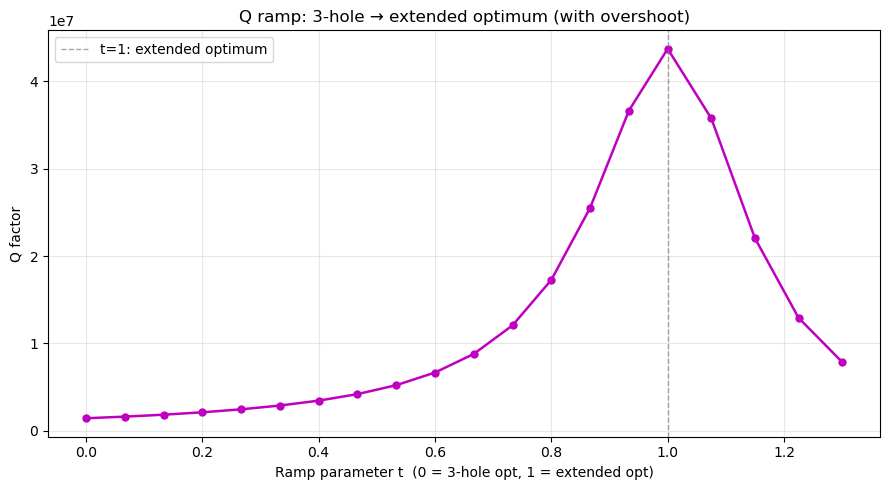

Results saved to data/2026-04-14_154911_extended_ramp_sweep/


In [44]:
# Extended design ramp: interpolate from 3-hole optimum → extended optimum (with overshoot)
#
# Uses per-step frequency tracking with eig_sigma updated to f_prev each step,
# so the eigensolver actively targets the cavity mode even as it shifts in frequency.
legume.set_backend('numpy')

# 3-hole base
dx_3h = np.zeros(nc);  dx_3h[0] = 0.27239;  dx_3h[1] = 0.21982
dy_3h = np.zeros(nc)

# Extended optimum target
dx_target = np.zeros(nc)
dy_target = np.zeros(nc)
dx_target[0]  =  0.27487;  dx_target[1]  =  0.23278
dx_target[2]  = -0.00241;  dx_target[3]  =  0.12142
dx_target[7]  =  0.00094;  dx_target[8]  =  0.00873;  dx_target[9]  =  0.00226
dy_target[7]  =  0.02053;  dy_target[8]  =  0.00237;  dy_target[9]  =  0.00513
dx_target[17] = -0.00962;  dx_target[18] = -0.01077
dy_target[16] =  0.01433;  dy_target[17] =  0.00565;  dy_target[18] =  0.01215

ddx = dx_target - dx_3h
ddy = dy_target - dy_3h

# t=1 guaranteed to be hit; overshoot to 1.3
t_vals = np.concatenate([np.linspace(0, 1, 16), np.linspace(1, 1.3, 5)[1:]])  # 20 sims

# Seed f_prev from the known correct mode at t=0 using the global mode_idx
gme_seed, _ = gme_cavity(dx_3h, dy_3h, gmax=2, truncate_g='tbt',
                          options={'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                                   'eig_sigma': f_target, 'gradients': 'approx'})
f_prev = float(gme_seed.freqs[0, mode_idx])
print(f"Seeded f_prev = {f_prev:.6f} from mode_idx={mode_idx} at t=0")

Qs_ext_ramp = []
freqs_ext_ramp = []

print("\nExtended ramp: 3-hole opt → extended optimum → overshoot")
print(f"  {'t':>5s}  {'mind':>5s}  {'freq':>10s}  {'Q':>14s}")
print("  " + "-" * 40)
for t in t_vals:
    dx_s = dx_3h + t * ddx
    dy_s = dy_3h + t * ddy

    phc_s = cavity(dx_s, dy_s)
    # Update eig_sigma to f_prev so solver targets the cavity mode's current frequency
    opts = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
            'eig_sigma': f_prev, 'gradients': 'approx', 'compute_im': False}
    gme_s = legume.GuidedModeExp(phc_s, gmax=2, truncate_g='tbt')
    gme_s.run(kpoints=np.array([[0], [0]]), **opts)

    all_freqs = gme_s.freqs[0]
    mind = int(np.argmin(np.abs(all_freqs - f_prev)))
    f_prev = float(all_freqs[mind])

    (freq_im, _, _) = gme_s.compute_rad(0, [mind])
    Q_s = float(all_freqs[mind] / (2 * freq_im[0]))
    Qs_ext_ramp.append(Q_s)
    freqs_ext_ramp.append(f_prev)
    print(f"  {t:5.2f}  {mind:5d}  {f_prev:10.6f}  {Q_s:14.1f}")

Qs_ext_ramp = np.array(Qs_ext_ramp)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_vals, Qs_ext_ramp, 'mo-', lw=1.8, ms=5)
ax.axvline(1.0, color='gray', ls='--', lw=1, alpha=0.7, label='t=1: extended optimum')
ax.set_xlabel('Ramp parameter t  (0 = 3-hole opt, 1 = extended opt)')
ax.set_ylabel('Q factor')
ax.set_title('Q ramp: 3-hole → extended optimum (with overshoot)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Save ---
if SAVE_DATA:
    save_sweep('extended_ramp_sweep', {
        't_vals':    t_vals,
        'Qs':        Qs_ext_ramp,
        'freqs':     np.array(freqs_ext_ramp),
        'dx_3h':     dx_3h,
        'dy_3h':     dy_3h,
        'dx_target': dx_target,
        'dy_target': dy_target,
    })


Seeded f_prev = 0.256908

      t   phase  mind        freq               Q
  ------------------------------------------------
   0.00       A     8    0.256908       1438926.2
   0.14       A     8    0.256720       1656151.4
   0.29       A     8    0.256536       1812157.5
   0.43       A     8    0.256354       1852309.5
   0.57       A     8    0.256175       1758257.8
   0.71       A     8    0.256000       1564303.4
   0.86       A     8    0.255827       1329431.2
   1.00       A     8    0.255657       1100915.2
   1.12       B     8    0.255657       1188560.0
   1.25       B     8    0.255656       1271348.7
   1.38       B     8    0.255655       1345191.2
   1.50       B     8    0.255655       1404334.3
   1.62       B     8    0.255655       1441234.3
   1.75       B     8    0.255654       1447003.0
   1.88       B     8    0.255654       1412880.2
   2.00       B     8    0.255654       1332941.1
   2.12       C     8    0.255636       1705903.6
   2.25       C     8  

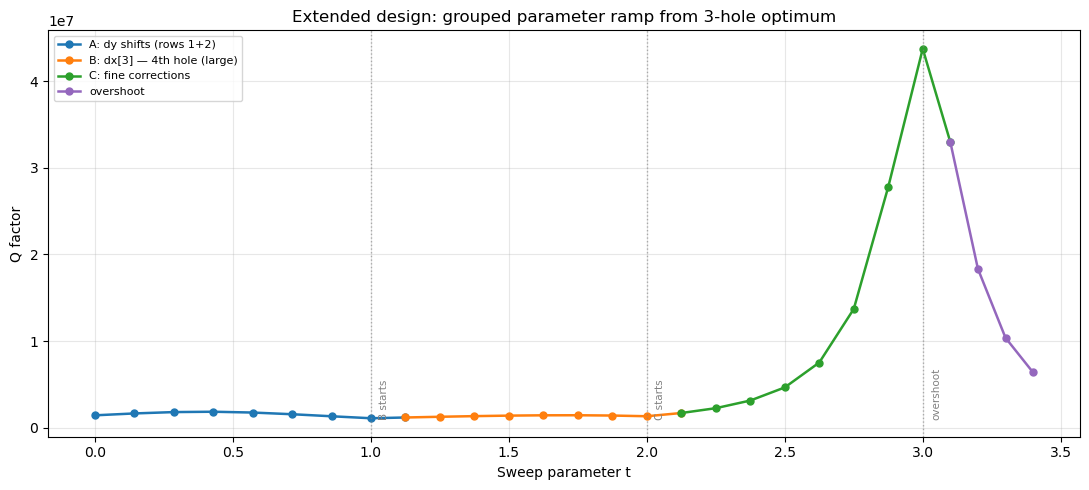

Results saved to data/2026-04-14_165849_extended_grouped_sweep/


In [14]:
# Extended grouped ramp: introduce parameter groups one at a time from 3-hole optimum
#
# Phase A (t=0→1): ramp all dy shifts (rows 1+2) — y-displacements of off-axis holes
# Phase B (t=1→2): ramp dx[3]=0.12a — the large 4th-hole shift along the cavity axis
# Phase C (t=2→3): ramp remaining fine corrections (dx[0,1] tweaks, row 1/2 dx, row 2 dy)
# Overshoot (t=3→3.4): all params past optimum
#
# Each phase reveals the individual contribution of that parameter group to Q.
legume.set_backend('numpy')

# 3-hole base
dx_3h = np.zeros(nc);  dx_3h[0] = 0.27239;  dx_3h[1] = 0.21982
dy_3h = np.zeros(nc)

# Extended optimum target
dx_tgt = np.zeros(nc)
dy_tgt = np.zeros(nc)
dx_tgt[0]  =  0.27487;  dx_tgt[1]  =  0.23278
dx_tgt[2]  = -0.00241;  dx_tgt[3]  =  0.12142
dx_tgt[7]  =  0.00094;  dx_tgt[8]  =  0.00873;  dx_tgt[9]  =  0.00226
dy_tgt[7]  =  0.02053;  dy_tgt[8]  =  0.00237;  dy_tgt[9]  =  0.00513
dx_tgt[17] = -0.00962;  dx_tgt[18] = -0.01077
dy_tgt[16] =  0.01433;  dy_tgt[17] =  0.00565;  dy_tgt[18] =  0.01215

# Phase A: all dy shifts (rows 1 and 2)
ddx_A = np.zeros(nc)
ddy_A = dy_tgt.copy()

# Phase B: the large 4th-hole dx[3] shift only
ddx_B = np.zeros(nc);  ddx_B[3] = dx_tgt[3]
ddy_B = np.zeros(nc)

# Phase C: everything remaining (dx[0,1] corrections, dx[2], row 1/2 dx)
ddx_C = dx_tgt - dx_3h - ddx_B
ddy_C = np.zeros(nc)

def interp_params(t):
    tA = np.clip(t,       0, 1)
    tB = np.clip(t - 1,   0, 1)
    tC = np.clip(t - 2,   0, 1.4)  # allow overshoot in phase C
    dx = dx_3h + tA * ddx_A + tB * ddx_B + tC * ddx_C
    dy = dy_3h + tA * ddy_A + tB * ddy_B + tC * ddy_C
    return dx, dy

Na, Nb, Nc, Nov = 8, 8, 8, 4  # steps per phase → 28 sims (~7 min)
t_vals = np.concatenate([
    np.linspace(0, 1, Na),
    np.linspace(1, 2, Nb + 1)[1:],
    np.linspace(2, 3, Nc + 1)[1:],
    np.linspace(3, 3.4, Nov + 1)[1:],
])

# Seed f_prev from known correct mode at 3-hole optimum
gme_seed, _ = gme_cavity(dx_3h, dy_3h, gmax=2, truncate_g='tbt',
                          options={'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                                   'eig_sigma': f_target, 'gradients': 'approx'})
f_prev = float(gme_seed.freqs[0, mode_idx])
print(f"Seeded f_prev = {f_prev:.6f}")

Qs_grp, freqs_grp = [], []
print(f"\n  {'t':>5s}  {'phase':>6s}  {'mind':>4s}  {'freq':>10s}  {'Q':>14s}")
print("  " + "-" * 48)
for t in t_vals:
    phase = 'A' if t <= 1 else ('B' if t <= 2 else ('C' if t <= 3 else 'over'))
    dx_s, dy_s = interp_params(t)
    phc_s = cavity(dx_s, dy_s)
    opts = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
            'eig_sigma': f_prev, 'gradients': 'approx', 'compute_im': False}
    gme_s = legume.GuidedModeExp(phc_s, gmax=2, truncate_g='tbt')
    gme_s.run(kpoints=np.array([[0], [0]]), **opts)
    all_freqs = gme_s.freqs[0]
    mind = int(np.argmin(np.abs(all_freqs - f_prev)))
    f_prev = float(all_freqs[mind])
    (freq_im, _, _) = gme_s.compute_rad(0, [mind])
    Q_s = float(all_freqs[mind] / (2 * freq_im[0]))
    Qs_grp.append(Q_s);  freqs_grp.append(f_prev)
    print(f"  {t:5.2f}  {phase:>6s}  {mind:4d}  {f_prev:10.6f}  {Q_s:14.1f}")

Qs_grp = np.array(Qs_grp)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
labels = ['A: dy shifts (rows 1+2)', 'B: dx[3] — 4th hole (large)',
          'C: fine corrections', 'overshoot']
boundaries = [0, Na, Na+Nb, Na+Nb+Nc, len(t_vals)]
for k in range(4):
    sl = slice(boundaries[k], boundaries[k+1] + (1 if k < 3 else 0))
    ax.plot(t_vals[sl], Qs_grp[sl], 'o-', color=colors[k], lw=1.8, ms=5, label=labels[k])
for tv, lbl in [(1, 'B starts'), (2, 'C starts'), (3, 'overshoot')]:
    ax.axvline(tv, color='gray', ls=':', lw=1, alpha=0.6)
    ax.text(tv+0.03, max(Qs_grp)*0.02, lbl, fontsize=7.5, color='gray', rotation=90, va='bottom')
ax.set_xlabel('Sweep parameter t')
ax.set_ylabel('Q factor')
ax.set_title('Extended design: grouped parameter ramp from 3-hole optimum')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if SAVE_DATA:
    save_sweep('extended_grouped_sweep', {
        't_vals': t_vals, 'Qs': Qs_grp,
        'freqs': np.array(freqs_grp),
    })


Loading from: data/2026-04-14_165849_extended_grouped_sweep


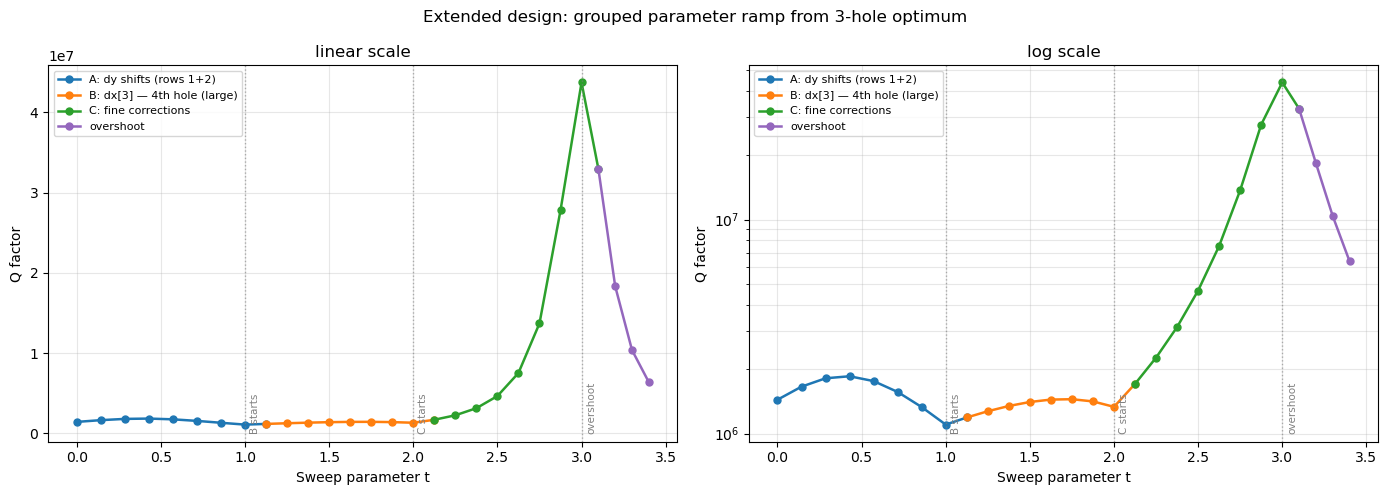

Peak Q = 43715163 at t = 3.000


In [17]:
# Load and plot saved extended grouped sweep data
import glob, os

sweep_dir = sorted(glob.glob('data/*_extended_grouped_sweep'))[-1]
print(f"Loading from: {sweep_dir}")

t_vals_loaded = np.load(os.path.join(sweep_dir, 't_vals.npy'))
Qs_loaded     = np.load(os.path.join(sweep_dir, 'Qs.npy'))
freqs_loaded  = np.load(os.path.join(sweep_dir, 'freqs.npy'))

Na, Nb, Nc, Nov = 8, 8, 8, 4
boundaries = [0, Na, Na+Nb, Na+Nb+Nc, len(t_vals_loaded)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
labels = ['A: dy shifts (rows 1+2)', 'B: dx[3] — 4th hole (large)',
          'C: fine corrections', 'overshoot']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Extended design: grouped parameter ramp from 3-hole optimum')

for ax, yscale in zip(axes, ['linear', 'log']):
    for k in range(4):
        sl = slice(boundaries[k], boundaries[k+1] + (1 if k < 3 else 0))
        ax.plot(t_vals_loaded[sl], Qs_loaded[sl], 'o-', color=colors[k],
                lw=1.8, ms=5, label=labels[k])
    ax.set_yscale(yscale)
    ax.set_xlabel('Sweep parameter t')
    ax.set_ylabel('Q factor')
    ax.set_title(f'{yscale} scale')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both' if yscale == 'log' else 'major')
    for tv, lbl in [(1, 'B starts'), (2, 'C starts'), (3, 'overshoot')]:
        ax.axvline(tv, color='gray', ls=':', lw=1, alpha=0.6)
        ax.text(tv+0.03, 0.02, lbl, fontsize=7.5, color='gray',
                rotation=90, va='bottom', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

print(f"Peak Q = {Qs_loaded.max():.0f} at t = {t_vals_loaded[Qs_loaded.argmax()]:.3f}")
